In [ ]:
# ── BLOQUE 1: Imports y configuracion global ──────────────────────────────
#
# Dataset: Endomondo / FitRec
# Paper:   Ni, Muhlstein & McAuley (2019). "Modeling heart rate and activity
#          data for personalized fitness recommendation". WWW'19, San Francisco.
# Descarga: https://cseweb.ucsd.edu/~jmcauley/datasets.html#endomondo
#
# El fichero que usamos es: endomondoHR_proper.json
#   - 167.373 sesiones de entrenamiento
#   - 956 usuarios
#   - Variables: heart_rate, derived_speed, altitude, timestamp,
#                gender, sport, userId
#   - Solo incluye sesiones con FC registrada (garantizado)

import ast
import json
import math
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings

from collections import defaultdict
from itertools import product
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score,
)
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

warnings.filterwarnings("ignore")

# ── Reproducibilidad ──────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Estilo de graficos ────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":     130,
    "figure.figsize": (11, 6),
    "font.size":      12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
})
sns.set_style("whitegrid")
sns.set_palette("Set2")

# ── Ruta al fichero descargado ────────────────────────────────────────────
DATA_PATH = Path("data/endomondoHR_proper.json")

# ── Features del modelo — (13 variables) ────
FEATURE_COLS = [
    "hr_mean_avg",       # FC media de entrenamiento (bpm)
    "hr_max_avg",        # FC maxima media alcanzada
    "hr_std_avg",        # Variabilidad FC intra-sesion media
    "speed_mean_avg",    # Velocidad media (km/h)
    "speed_max_avg",     # Velocidad punta media
    "speed_std_avg",     # Variabilidad de velocidad intra-sesion media
    "elevation_avg",     # Desnivel acumulado medio por sesion (m)
    "duration_avg",      # Duracion media de sesion (min)
    "distance_avg",      # Distancia media por sesion (km)
    "weekly_sessions",   # Frecuencia semanal media de entrenamiento
    "weekly_km",         # Volumen semanal medio (km)
    "hr_speed_ratio",    # Ratio FC/velocidad — proxy de eficiencia cardiaca
    "speed_consistency", # Coeficiente de variacion de velocidad entre sesiones
]

print("✅ Configuracion completada.")
print(f"   Fichero de datos  : {DATA_PATH}")
print(f"   Features del modelo: {len(FEATURE_COLS)}")
print()
print("⚠️  Asegurate de haber descargado endomondoHR_proper.json desde:")
print("   https://cseweb.ucsd.edu/~jmcauley/datasets.html#endomondo")


In [ ]:
# ── ANÁLISIS DE DISTRIBUCION POR DEPORTE ──────────────────────────────────
# Antes de filtrar solo running, analizamos que deportes hay en el dataset
# completo y cuantos usuarios y sesiones tiene cada uno.

print("Analizando distribucion de deportes en el dataset completo...")
print("(puede tardar unos segundos)\n")

sport_stats = defaultdict(lambda: {"sesiones": 0, "usuarios": set()})

with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        try:
            workout = ast.literal_eval(line.strip())
            sport   = workout.get("sport", "desconocido").lower().strip()
            user    = workout.get("userId")
            sport_stats[sport]["sesiones"] += 1
            sport_stats[sport]["usuarios"].add(user)
        except Exception:
            continue

# ── Construir DataFrame de resultados ─────────────────────────────────────
df_sports = (
    pd.DataFrame.from_records([
        {
            "deporte":          sport,
            "n_sesiones":       s["sesiones"],
            "n_usuarios":       len(s["usuarios"]),
            "sesiones_usuario": round(s["sesiones"] / len(s["usuarios"]), 1),
        }
        for sport, s in sport_stats.items()
    ])
    .sort_values("n_sesiones", ascending=False)
    .reset_index(drop=True)
)

# ── Mostrar tabla ──────────────────────────────────────────────────────────
print("=== Distribucion por deporte — Dataset Endomondo completo ===\n")
print(f"{'Deporte':<30} | {'Sesiones':>9} | {'Usuarios':>9} | {'Ses/Usuario':>12}")
print("-" * 68)
for _, row in df_sports.iterrows():
    print(f"  {row['deporte']:<28} | {row['n_sesiones']:>9,} | "
          f"{row['n_usuarios']:>9,} | {row['sesiones_usuario']:>12.1f}")

print(f"\n  TOTAL: {df_sports['n_sesiones'].sum():,} sesiones | "
      f"{df_sports['n_usuarios'].max():,} usuarios unicos")

# ── Visualizacion ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
top_sports = df_sports.head(12)
colors_bar = plt.cm.Set2(np.linspace(0, 1, len(top_sports)))

axes[0].barh(top_sports["deporte"][::-1],
             top_sports["n_sesiones"][::-1],
             color=colors_bar[::-1], edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Numero de sesiones")
axes[0].set_title("Sesiones por deporte", fontsize=12, fontweight="bold")
for i, (_, row) in enumerate(top_sports[::-1].iterrows()):
    axes[0].text(row["n_sesiones"] + 200, i,
                 f"{row['n_sesiones']:,}", va="center", fontsize=9)

axes[1].barh(top_sports["deporte"][::-1],
             top_sports["n_usuarios"][::-1],
             color=colors_bar[::-1], edgecolor="white", alpha=0.85)
axes[1].set_xlabel("Numero de usuarios unicos")
axes[1].set_title("Usuarios unicos por deporte", fontsize=12, fontweight="bold")
for i, (_, row) in enumerate(top_sports[::-1].iterrows()):
    axes[1].text(row["n_usuarios"] + 5, i,
                 f"{row['n_usuarios']:,}", va="center", fontsize=9)

plt.suptitle("Distribucion del dataset Endomondo por deporte",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("distribucion_deportes.png", bbox_inches="tight", dpi=130)
plt.show()
print("✅ distribucion_deportes.png guardado")

# ── Deportes candidatos ───────────────────────────────────────────────────
print("\n💡 Deportes con >100 usuarios — candidatos para ampliar el analisis:")
for _, row in df_sports[df_sports["n_usuarios"] >= 100].iterrows():
    print(f"   · {row['deporte']:<25} "
          f"{row['n_sesiones']:>6,} sesiones | "
          f"{row['n_usuarios']:>4} usuarios | "
          f"{row['sesiones_usuario']:>5.1f} ses/usuario")


In [ ]:
# ── BLOQUE 2 ACTUALIZADO: Carga + calculo de speed desde GPS ──────────────
#
# Para sesiones sin campo 'speed', calculamos la velocidad a partir de
# las coordenadas GPS (latitud, longitud) y los timestamps usando la
# formula de Haversine, que calcula la distancia entre dos puntos


def haversine(lat1, lon1, lat2, lon2) -> float:
    """
    Calcula la distancia en metros entre dos puntos GPS
    usando la formula de Haversine.

    Parametros
    ----------
    lat1, lon1 : coordenadas del punto 1 (grados decimales)
    lat2, lon2 : coordenadas del punto 2 (grados decimales)

    Retorna
    -------
    float : distancia en metros
    """
    R = 6371000  # radio de la Tierra en metros

    phi1    = math.radians(lat1)
    phi2    = math.radians(lat2)
    dphi    = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)

    a = (math.sin(dphi / 2) ** 2 +
         math.cos(phi1) * math.cos(phi2) *
         math.sin(dlambda / 2) ** 2)

    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))


def calculate_speed_from_gps(lat: list, lon: list,
                              ts: list) -> list:
    """
    Calcula la velocidad en km/h entre cada par de puntos GPS consecutivos.

    Parametros
    ----------
    lat, lon : listas de coordenadas GPS
    ts       : lista de timestamps Unix (segundos)

    Retorna
    -------
    list : velocidades en km/h (una por intervalo entre puntos)
    """
    speeds = []

    for i in range(1, len(ts)):
        dt = ts[i] - ts[i - 1]  # segundos entre mediciones

        # Evitar division por cero o intervalos negativos
        if dt <= 0:
            continue

        dist_m = haversine(lat[i-1], lon[i-1], lat[i], lon[i])
        speed_kmh = (dist_m / dt) * 3.6  # convertir m/s a km/h

        # Filtrar velocidades imposibles en running
        if 0 <= speed_kmh <= 35:
            speeds.append(speed_kmh)

    return speeds


def extract_session_metrics(workout: dict) -> dict | None:
    """
    Extrae metricas agregadas de una sesion de running.
    Si no hay campo 'speed', lo calcula desde GPS.
    Devuelve None si no es running o faltan datos suficientes.
    """
    # ── Filtrar solo running ───────────────────────────────────────────────
    sport = workout.get("sport", "").lower()
    if sport != "run":
        return None

    hr  = workout.get("heart_rate", [])
    ts  = workout.get("timestamp", [])
    alt = workout.get("altitude", [])

    # ── Obtener velocidad: campo directo o calculo desde GPS ──────────────
    speed = workout.get("speed", [])

    if len(speed) < 10:
        # Intentar calcular desde GPS
        lat = workout.get("latitude", [])
        lon = workout.get("longitude", [])

        if len(lat) >= 10 and len(lon) >= 10 and len(ts) >= 10:
            speed = calculate_speed_from_gps(lat, lon, ts)
        else:
            return None  # sin speed ni GPS suficiente

    # ── Validaciones mínimas ───────────────────────────────────────────────
    if len(hr) < 10 or len(speed) < 10:
        return None

    # Filtrar valores físicamente imposibles
    hr    = [v for v in hr    if 40  <= v <= 220]
    speed = [v for v in speed if 0   <= v <= 35 ]

    if len(hr) < 10 or len(speed) < 10:
        return None

    if len(ts) < 2:
        return None

    duration_min = (ts[-1] - ts[0]) / 60
    if duration_min < 5 or duration_min > 300:
        return None

    # ── Distancia estimada ────────────────────────────────────────────────
    distance_km = np.mean(speed) * (duration_min / 60)

    # ── Desnivel positivo acumulado ───────────────────────────────────────
    if len(alt) >= 2:
        diffs = np.diff(alt)
        elevation_gain = float(np.sum(diffs[diffs > 0]))
    else:
        elevation_gain = 0.0

    # ── Ratio FC / velocidad ──────────────────────────────────────────────
    hr_speed_ratio = (
        np.mean(hr) / np.mean(speed) if np.mean(speed) > 0 else None
    )

    return {
        "user_id":        workout.get("userId"),
        "gender":         workout.get("gender", "unknown"),
        "hr_mean":        float(np.mean(hr)),
        "hr_max":         float(np.max(hr)),
        "hr_std":         float(np.std(hr)),
        "speed_mean":     float(np.mean(speed)),
        "speed_max":      float(np.max(speed)),
        "speed_std":      float(np.std(speed)),
        "elevation_gain": elevation_gain,
        "duration_min":   duration_min,
        "distance_km":    distance_km,
        "hr_speed_ratio": hr_speed_ratio,
        "speed_from_gps": len(workout.get("speed", [])) < 10,  # flag
    }


# ── Cargar o procesar fichero completo ────────────────────────────────────
CSV_SESSIONS = "endomondo_running_sessions.csv"

if os.path.exists(CSV_SESSIONS):
    df_sessions = pd.read_csv(CSV_SESSIONS)
    print(f"✅ CSV cargado desde cache: {len(df_sessions):,} sesiones")
    print(f"   Usuarios unicos: {df_sessions['user_id'].nunique()}")
else:
    print("Cargando y filtrando sesiones de running de Endomondo...")
    print("(fichero completo — puede tardar 2-3 minutos)\n")

    sessions  = []
    n_total   = 0
    n_running = 0
    n_gps     = 0
    n_skipped = 0

    with open(DATA_PATH, "r", encoding="utf-8") as f:
        for line in f:
            try:
                workout = ast.literal_eval(line.strip())
                n_total += 1
                metrics = extract_session_metrics(workout)
                if metrics:
                    if metrics["speed_from_gps"]:
                        n_gps += 1
                    sessions.append(metrics)
                    n_running += 1
                else:
                    n_skipped += 1
            except Exception:
                n_skipped += 1

    df_sessions = pd.DataFrame(sessions)

    print(f"✅ Procesamiento completado.")
    print(f"   Sesiones totales          : {n_total:,}")
    print(f"   Sesiones de running       : {n_running:,}")
    print(f"     · Speed directo         : {n_running - n_gps:,}")
    print(f"     · Speed desde GPS       : {n_gps:,}")
    print(f"   Descartadas               : {n_skipped:,}")
    print(f"   Usuarios unicos           : {df_sessions['user_id'].nunique()}")

    print(f"\n=== Valores nulos por columna ===")
    nulos = df_sessions.isnull().sum()
    pct   = (nulos / len(df_sessions) * 100).round(1)
    print(pd.DataFrame({"nulos": nulos, "% faltante": pct}))

    print(f"\n=== Estadísticos descriptivos ===")
    display(df_sessions.describe().round(2))

    df_sessions.to_csv(CSV_SESSIONS, index=False)
    print("\n✅ Guardado: endomondo_running_sessions.csv")


✅ CSV cargado desde caché: 70,481 sesiones
   Usuarios únicos: 805


In [ ]:
# ── BLOQUE 3: Feature Engineering por usuario ─────────────────────────────
#
# Hasta ahora tenemos una fila por SESION (11.530 filas, 472 usuarios).
# Ahora agregamos las sesiones de cada usuario en UN UNICO VECTOR
# que representa su perfil global de entrenamiento.
#
# Este vector es el input del modelo K-Means.
#
# Features construidas y justificacion bibliografica
# ───────────────────────────────────────────────────
# hr_mean_avg       → FC media global — intensidad habitual de entrenamiento
# hr_max_avg        → FC maxima media — capacidad cardiovascular
# hr_std_avg        → Variabilidad FC intra-sesion media — proxy de HRV
# speed_mean_avg    → Velocidad media global — rendimiento aerobico
# speed_max_avg     → Velocidad punta media — capacidad anaerobica
# speed_std_avg     → Variabilidad de velocidad media — tipo de entrenamiento
#                     (intervalos vs rodaje continuo)
# elevation_avg     → Desnivel medio por sesion — tipo de terreno habitual
# duration_avg      → Duracion media de sesion (min)
# distance_avg      → Distancia media por sesion (km)
# weekly_sessions   → Frecuencia semanal media de entrenamiento
# weekly_km         → Volumen semanal medio (km) — carga de entrenamiento
# hr_speed_ratio    → Ratio FC/velocidad — eficiencia cardiaca global
# speed_consistency → 1 - (std velocidad entre sesiones / mean velocidad)
#                     Consistencia del rendimiento a lo largo del tiempo

def build_user_features(df: pd.DataFrame,
                         min_sessions: int = 5) -> pd.DataFrame:
    """
    Agrega las sesiones por usuario y construye el vector de features.

    Parametros
    ----------
    df           : DataFrame de sesiones (output del Bloque 2)
    min_sessions : mínimo de sesiones para incluir al usuario.
                   Usuarios con menos sesiones no tienen perfil
                   estadísticamente representativo.

    Retorna
    -------
    DataFrame con una fila por usuario y sus features agregadas.
    """
    # ── Calcular semana de cada sesion para features temporales ───────────
    # Usamos el índice de sesion como proxy temporal ya que no tenemos
    # fecha en el fichero — las sesiones estan ordenadas por usuario
    df = df.copy()
    df["session_idx"] = df.groupby("user_id").cumcount()
    df["week_approx"] = df["session_idx"] // 3   # ~3 sesiones/semana aprox

    # ── Agregacion principal por usuario ──────────────────────────────────
    agg = df.groupby("user_id").agg(
        n_sessions        = ("hr_mean",        "count"),
        gender            = ("gender",          "first"),
        # FC
        hr_mean_avg       = ("hr_mean",        "mean"),
        hr_max_avg        = ("hr_max",         "mean"),
        hr_std_avg        = ("hr_std",         "mean"),
        # Velocidad
        speed_mean_avg    = ("speed_mean",     "mean"),
        speed_max_avg     = ("speed_max",      "mean"),
        speed_std_avg     = ("speed_std",      "mean"),
        speed_consistency = ("speed_mean",     "std"),
        # Terreno y volumen
        elevation_avg     = ("elevation_gain", "mean"),
        duration_avg      = ("duration_min",   "mean"),
        distance_avg      = ("distance_km",    "mean"),
        # Eficiencia
        hr_speed_ratio    = ("hr_speed_ratio", "mean"),
    ).reset_index()

    # ── Frecuencia y volumen semanal ───────────────────────────────────────
    weekly = (
        df.groupby(["user_id", "week_approx"])
        .agg(
            sessions_week = ("hr_mean",    "count"),
            km_week       = ("distance_km","sum"),
        )
        .reset_index()
        .groupby("user_id")
        .agg(
            weekly_sessions = ("sessions_week", "mean"),
            weekly_km       = ("km_week",       "mean"),
        )
        .reset_index()
    )

    features = agg.merge(weekly, on="user_id", how="left")

    # ── Consistencia de velocidad normalizada ─────────────────────────────
    # Coeficiente de variacion: menor valor = mas consistente
    features["speed_consistency"] = (
        features["speed_consistency"] / features["speed_mean_avg"]
    ).fillna(0)

    # ── Filtrar usuarios con pocas sesiones ───────────────────────────────
    before = len(features)
    features = features[features["n_sessions"] >= min_sessions].copy()
    after = len(features)
    print(f"   Usuarios eliminados por <{min_sessions} sesiones: "
          f"{before - after}")

    return features.reset_index(drop=True)


# ── Construir o cargar perfiles de usuario ────────────────────────────────
CSV_USERS = "endomondo_user_profiles.csv"

if os.path.exists(CSV_USERS):
    df_users = pd.read_csv(CSV_USERS)
    print(f"Perfiles cargados desde cache: {len(df_users)} usuarios")
else:
    print("Construyendo perfil de cada usuario...")
    df_users = build_user_features(df_sessions, min_sessions=5)

    print(f"Perfiles de usuario construidos.")
    print(f"   Usuarios totales          : {len(df_users)}")
    print(f"   Sesiones medias/usuario   : {df_users['n_sessions'].mean():.1f}")
    print(f"   Sesiones mín/max          : "
          f"{df_users['n_sessions'].min()} / {df_users['n_sessions'].max()}")
    print(f"   Genero (M/F)              : "
          f"{df_users['gender'].value_counts().to_dict()}")

    print(f"\n=== Features por usuario ===")
    display(df_users.drop(columns=["user_id","gender"]).describe().round(2))

    print(f"\n=== Primeras filas ===")
    display(df_users.head(8))

    df_users.to_csv(CSV_USERS, index=False)
    print("Guardado: endomondo_user_profiles.csv")


✅ Perfiles cargados desde caché: 693 usuarios


In [ ]:
# ── BLOQUE 4: Analisis Exploratorio de Datos (EDA) ────────────────────────
#
# Objetivo: entender la distribucion de las variables antes de modelar.
#
# Generamos 4 visualizaciones:
#   4.1 Distribuciones univariadas de cada feature
#   4.2 Matriz de correlaciones
#   4.3 Distribucion de sesiones por usuario
#   4.4 Comparativa por genero

# ── 4.1 Distribuciones univariadas ────────────────────────────────────────
n_cols = 4
n_rows = (len(FEATURE_COLS) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()
colors = sns.color_palette("Set2", len(FEATURE_COLS))

for i, col in enumerate(FEATURE_COLS):
    axes[i].hist(df_users[col].dropna(), bins=30,
                 color=colors[i], edgecolor="white", alpha=0.85)
    axes[i].axvline(df_users[col].mean(), color="red",
                    linestyle="--", linewidth=1.5, label="media")
    axes[i].axvline(df_users[col].median(), color="navy",
                    linestyle=":", linewidth=1.5, label="mediana")
    axes[i].set_title(col.replace("_", " ").title(), fontsize=10)
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Usuarios")
    axes[i].legend(fontsize=7)

for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribucion de features por usuario — Endomondo Dataset",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eda_distribuciones.png", bbox_inches="tight", dpi=130)
plt.show()
print("Grafico guardado: eda_distribuciones.png")


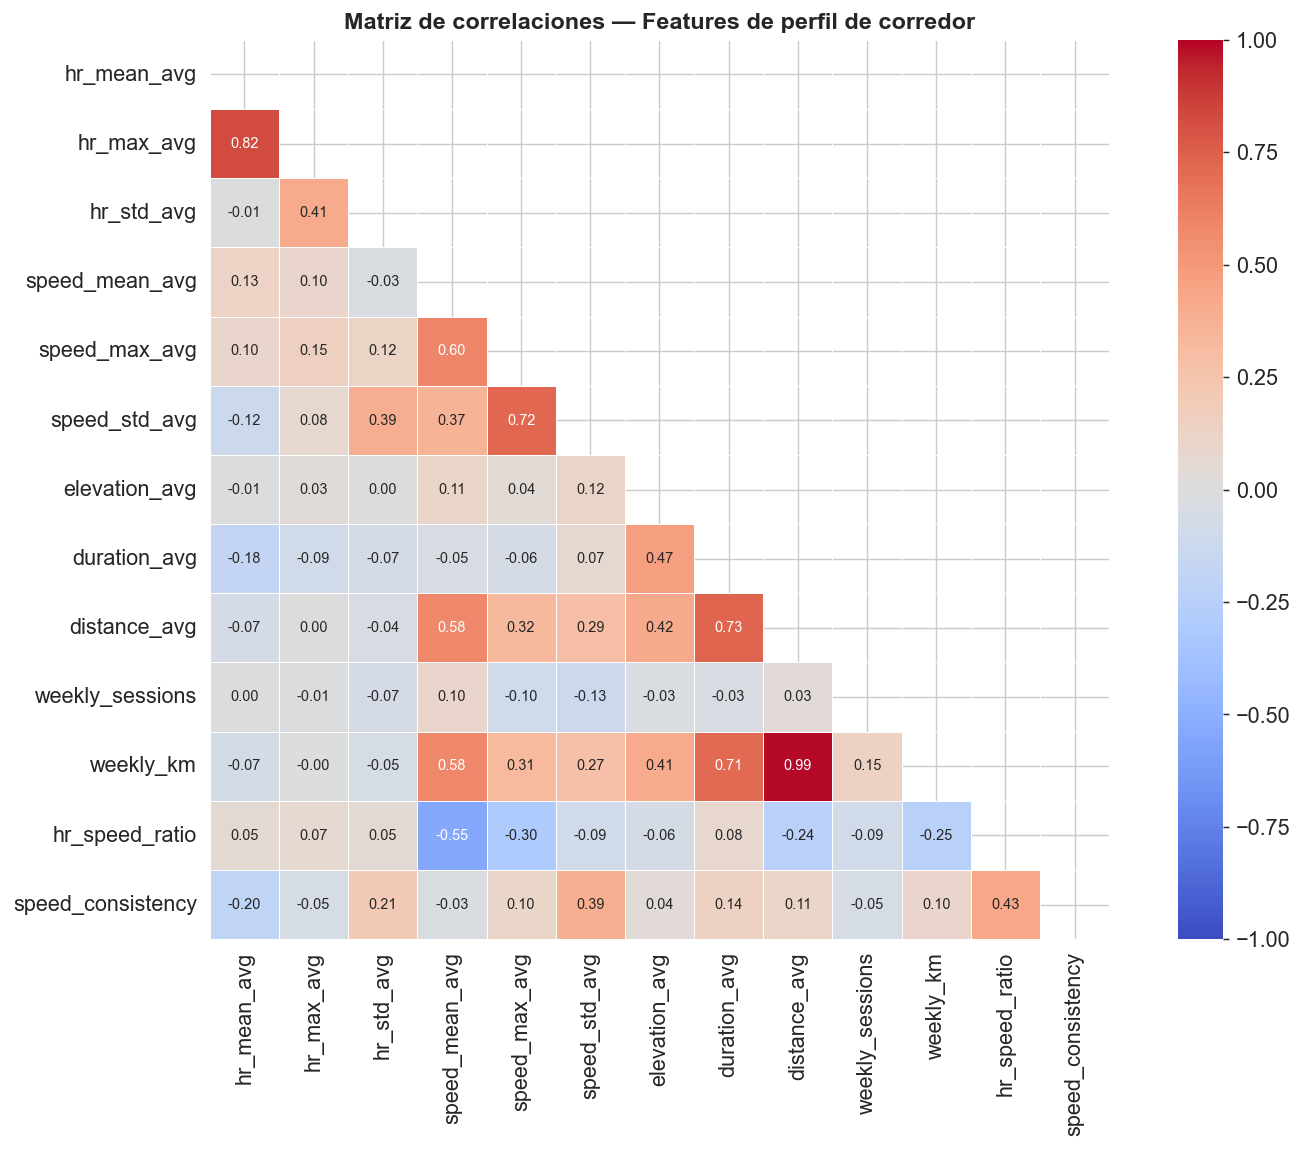

=== Pares con correlación > 0.6 ===
    feature_1      feature_2  correlacion
    weekly_km   distance_avg     0.992041
   hr_max_avg    hr_mean_avg     0.823380
 distance_avg   duration_avg     0.727336
speed_std_avg  speed_max_avg     0.722301
    weekly_km   duration_avg     0.713441
speed_max_avg speed_mean_avg     0.600789


In [ ]:
# ── 4.2 Matriz de correlaciones ───────────────────────────────────────────
corr = df_users[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    annot_kws={"size": 8},
)
ax.set_title("Matriz de correlaciones — Features de perfil de corredor",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_correlaciones.png", bbox_inches="tight", dpi=130)
plt.show()

# Correlaciones mas altas (útil para el TFM)
print("=== Pares con correlacion > 0.6 ===")
corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["feature_1", "feature_2", "correlacion"]
altas = corr_pairs[corr_pairs["correlacion"].abs() > 0.6].sort_values(
    "correlacion", ascending=False
)
print(altas.to_string(index=False))

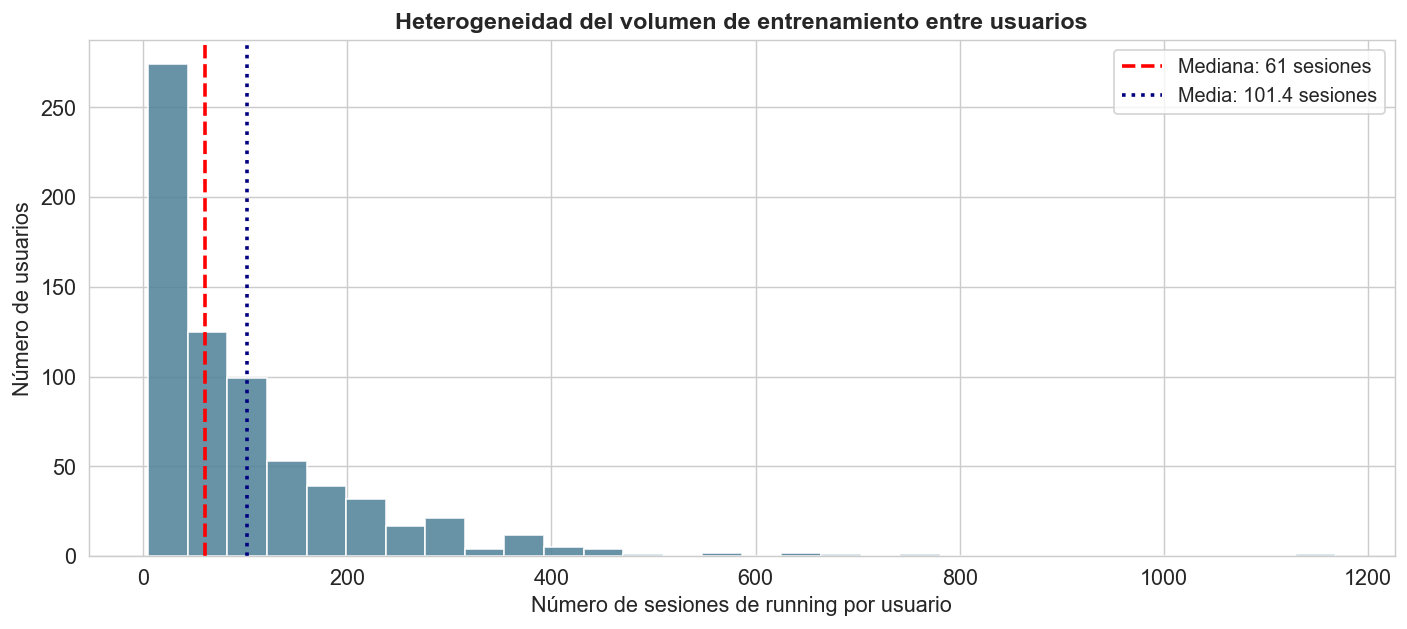

Usuarios con ≥ 20 sesiones : 550 (79.4%)
Usuarios con ≥ 50 sesiones : 396 (57.1%)


In [ ]:
# ── 4.3 Distribucion de sesiones por usuario ──────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(df_users["n_sessions"], bins=30,
        color="#4E8098", edgecolor="white", alpha=0.85)
ax.axvline(df_users["n_sessions"].median(), color="red",
           linestyle="--", linewidth=2,
           label=f"Mediana: {df_users['n_sessions'].median():.0f} sesiones")
ax.axvline(df_users["n_sessions"].mean(), color="navy",
           linestyle=":", linewidth=2,
           label=f"Media: {df_users['n_sessions'].mean():.1f} sesiones")

ax.set_xlabel("Número de sesiones de running por usuario")
ax.set_ylabel("Número de usuarios")
ax.set_title("Heterogeneidad del volumen de entrenamiento entre usuarios",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("eda_sesiones_usuario.png", bbox_inches="tight", dpi=130)
plt.show()

print(f"Usuarios con ≥ 20 sesiones : "
      f"{(df_users['n_sessions'] >= 20).sum()} "
      f"({(df_users['n_sessions'] >= 20).mean()*100:.1f}%)")
print(f"Usuarios con ≥ 50 sesiones : "
      f"{(df_users['n_sessions'] >= 50).sum()} "
      f"({(df_users['n_sessions'] >= 50).mean()*100:.1f}%)")

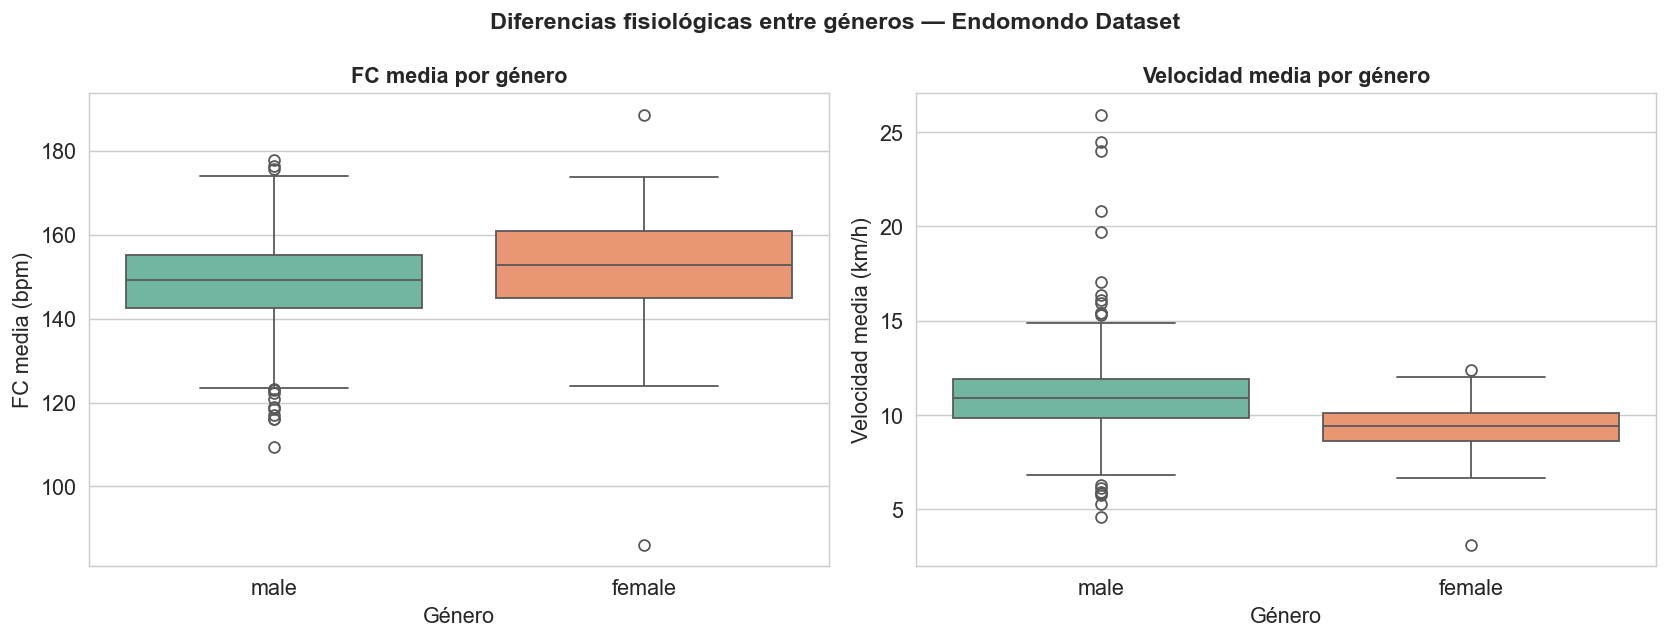

=== Medias por género ===
        hr_mean_avg  speed_mean_avg  weekly_km  n_sessions
gender                                                    
female       152.82            9.32      31.66       75.85
male         148.47           10.92      35.53      104.98


In [ ]:
# ── 4.4 Comparativa FC y velocidad por genero ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# FC media por genero
df_gender = df_users[df_users["gender"].isin(["male", "female"])]

sns.boxplot(data=df_gender, x="gender", y="hr_mean_avg",
            palette="Set2", ax=axes[0])
axes[0].set_title("FC media por genero", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Genero")
axes[0].set_ylabel("FC media (bpm)")

# Velocidad media por genero
sns.boxplot(data=df_gender, x="gender", y="speed_mean_avg",
            palette="Set2", ax=axes[1])
axes[1].set_title("Velocidad media por genero", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Genero")
axes[1].set_ylabel("Velocidad media (km/h)")

plt.suptitle("Diferencias fisiologicas entre generos — Endomondo Dataset",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_genero.png", bbox_inches="tight", dpi=130)
plt.show()

# Estadísticos por genero
print("=== Medias por genero ===")
print(df_gender.groupby("gender")[["hr_mean_avg", "speed_mean_avg",
                                    "weekly_km", "n_sessions"]].mean().round(2))

In [ ]:
# ── BLOQUE 5: Preprocesamiento ─────────────────────────────────────────────
#
# Fase "Data Preparation"
#
# Pasos:
#   1. Seleccion de features
#   2. Deteccion y eliminacion de outliers extremos (IQR × 3)
#   3. Normalizacion con StandardScaler (media=0, std=1)
#
# K-Means es sensible a la escala de las variables — sin normalizar,
# variables como weekly_km dominarían el calculo de distancias sobre
# variables como weekly_sessions simplemente por tener valores mas grandes.
#
# No hay imputacion porque el EDA confirmo 0% de nulos en todas las features.

def preprocess(df_users: pd.DataFrame,
               feature_cols: list) -> tuple:
    """
    Limpia y normaliza las features para K-Means.

    Retorna
    -------
    X_scaled   : np.ndarray normalizado — input del modelo
    X_clean    : pd.DataFrame con datos limpios sin normalizar
    scaler     : StandardScaler ajustado (para inverse_transform)
    ids        : pd.Series con user_id de cada fila
    """
    X = df_users[["user_id"] + feature_cols].copy()

    ids = X["user_id"].reset_index(drop=True)
    X   = X[feature_cols].copy()

    # ── Paso 1: Outliers extremos (IQR × 3) ──────────────────────────────
    # Usamos IQR × 3 en lugar del estandar × 1.5 para ser conservadores
    # y no perder usuarios con perfiles extremos pero validos
    # (ej. corredores de ultra-maraton con volumenes muy altos)
    mask = pd.Series([True] * len(X))

    print("=== Deteccion de outliers (IQR × 3) ===")
    for col in feature_cols:
        Q1  = X[col].quantile(0.25)
        Q3  = X[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 3 * IQR
        upper = Q3 + 3 * IQR
        outliers = ~X[col].between(lower, upper)
        if outliers.sum() > 0:
            print(f"   {col:<22}: {outliers.sum()} outliers "
                  f"(rango valido: {lower:.2f} – {upper:.2f})")
        mask = mask & ~outliers

    n_antes  = len(X)
    X        = X[mask.values].reset_index(drop=True)
    ids      = ids[mask.values].reset_index(drop=True)
    n_despues = len(X)
    print(f"\n   Usuarios antes  : {n_antes}")
    print(f"   Usuarios despues: {n_despues}")
    print(f"   Eliminados      : {n_antes - n_despues}")

    # ── Paso 2: Normalizacion StandardScaler ──────────────────────────────
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    print(f"\n✅ Preprocesamiento completado.")
    print(f"   Shape final para K-Means: {X_scaled.shape}")

    return X_scaled, X, scaler, ids


# ── Ejecutar ──────────────────────────────────────────────────────────────
X_scaled, X_clean, scaler, user_ids = preprocess(df_users, FEATURE_COLS)

=== Detección de outliers (IQR × 3) ===
   hr_mean_avg           : 1 outliers (rango válido: 103.34 – 194.94)
   hr_max_avg            : 1 outliers (rango válido: 122.60 – 217.90)
   hr_std_avg            : 2 outliers (rango válido: 0.72 – 22.71)
   speed_mean_avg        : 6 outliers (rango válido: 2.90 – 18.47)
   speed_max_avg         : 3 outliers (rango válido: 3.06 – 34.82)
   speed_std_avg         : 11 outliers (rango válido: -0.76 – 4.77)
   elevation_avg         : 17 outliers (rango válido: -210.44 – 506.94)
   duration_avg          : 3 outliers (rango válido: -9.51 – 143.91)
   distance_avg          : 4 outliers (rango válido: -2.82 – 26.38)
   weekly_sessions       : 30 outliers (rango válido: 2.56 – 3.33)
   weekly_km             : 4 outliers (rango válido: -9.83 – 78.89)
   hr_speed_ratio        : 9 outliers (rango válido: 3.21 – 25.76)
   speed_consistency     : 27 outliers (rango válido: -0.16 – 0.39)

   Usuarios antes  : 693
   Usuarios después: 610
   Eliminados      : 

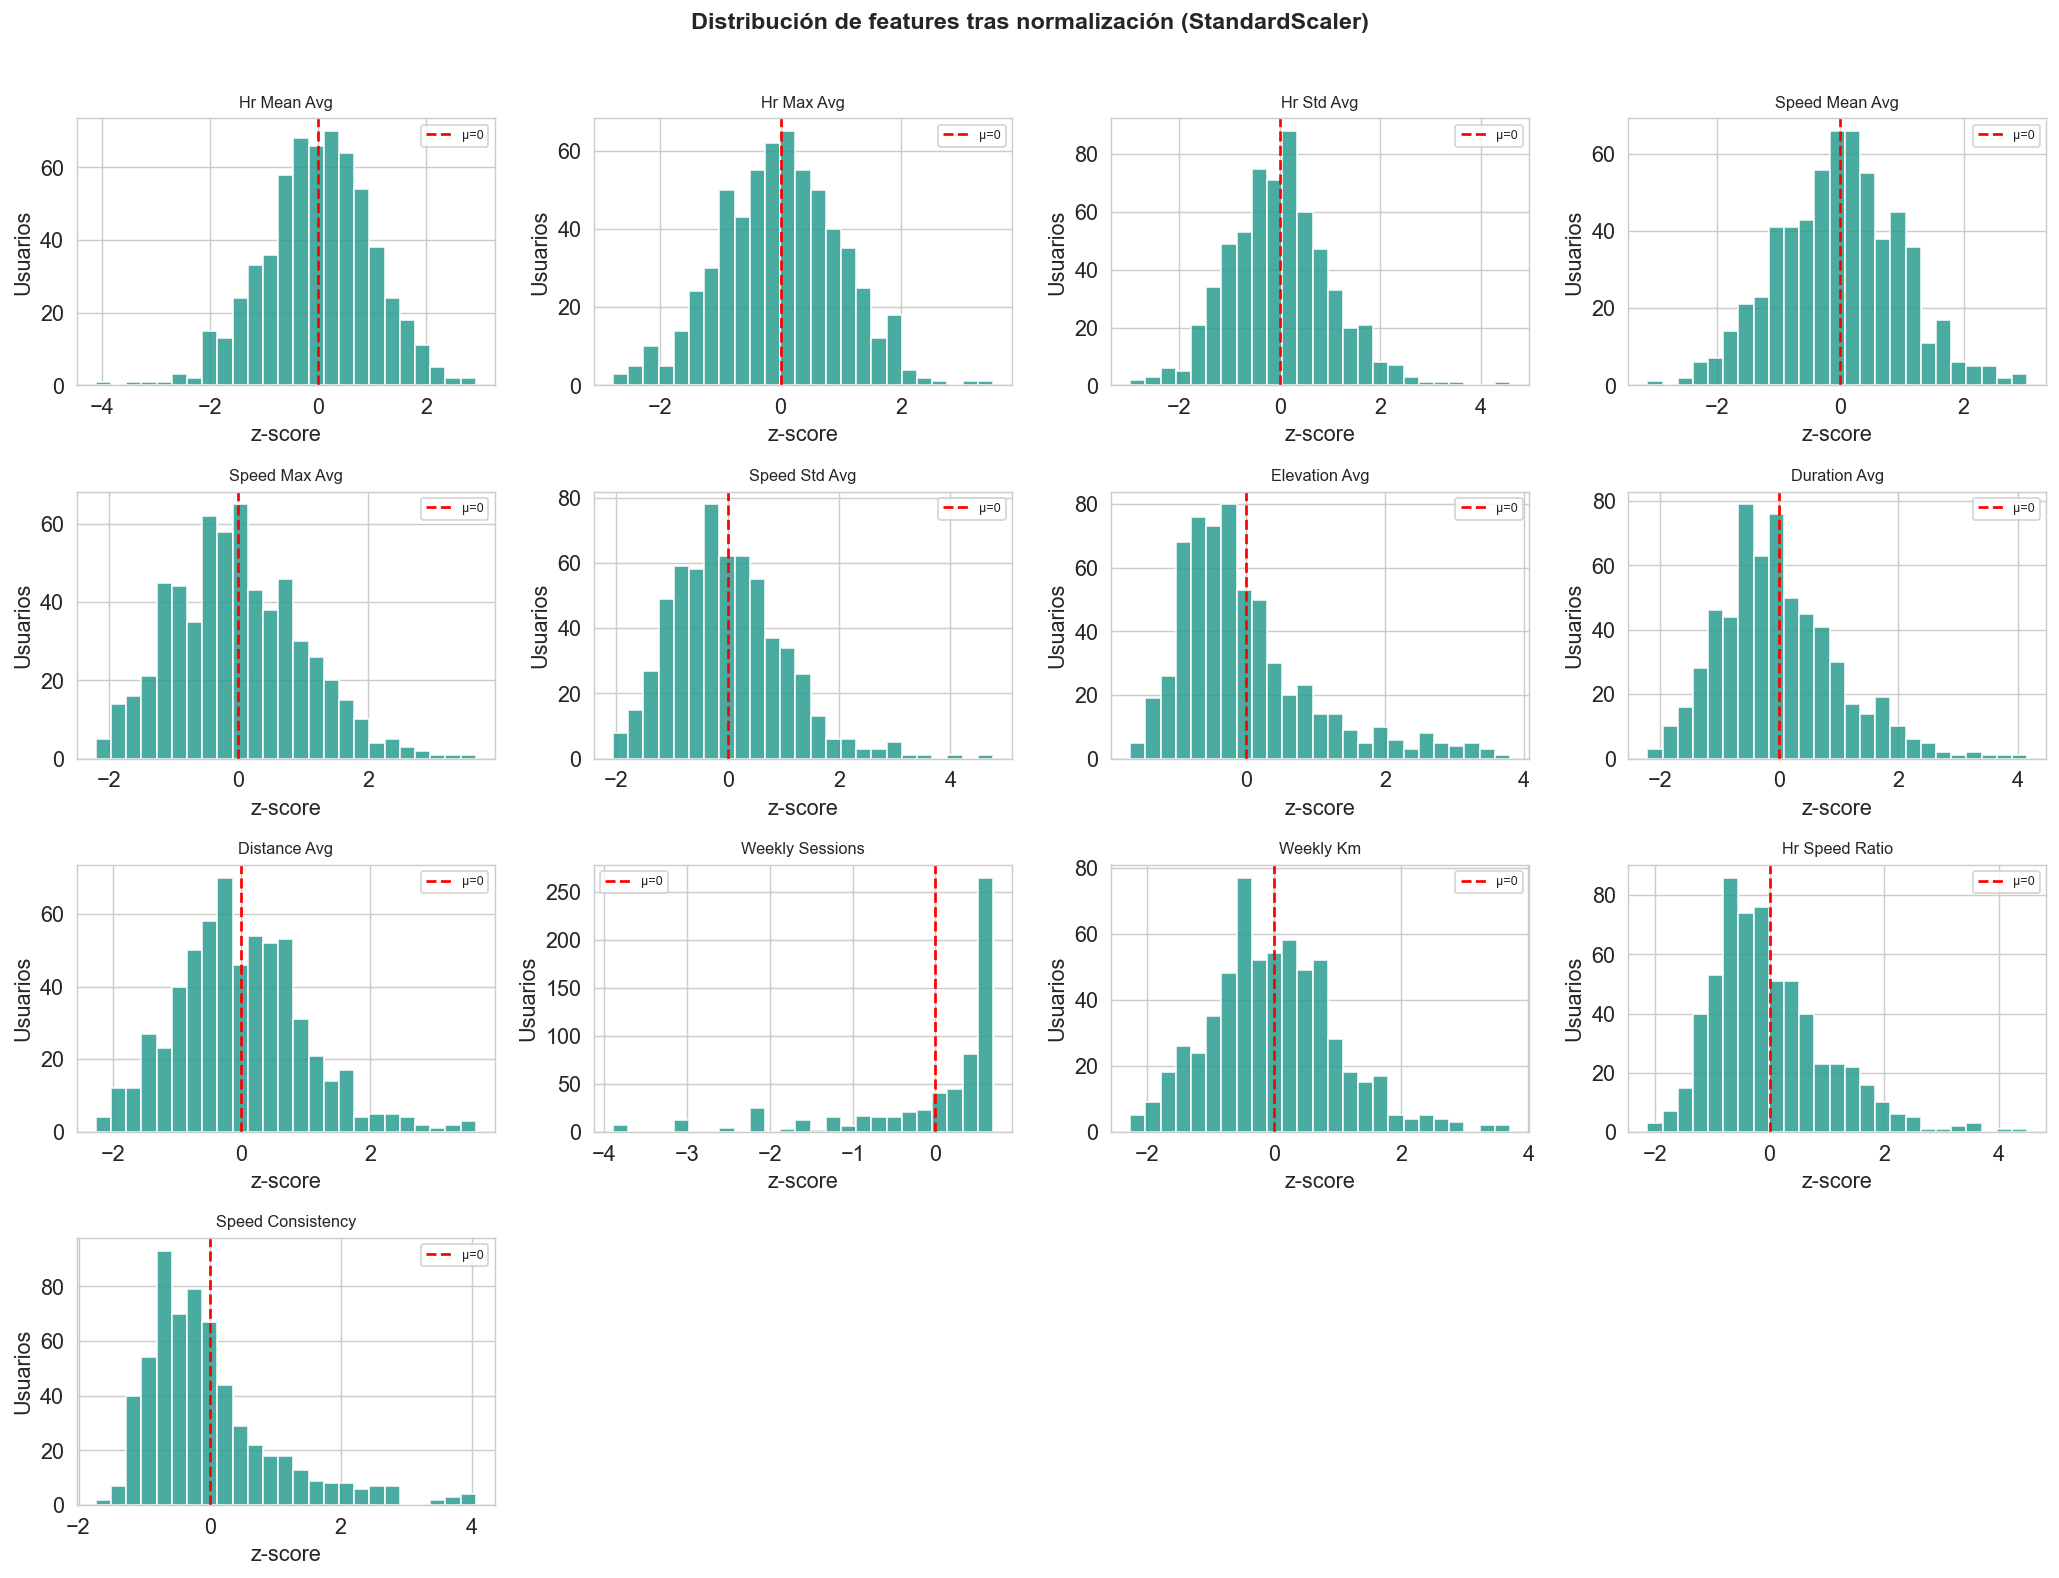

✅ Gráfico guardado: features_normalizadas.png


In [ ]:
# ── Verificar distribuciones tras normalizacion ───────────────────────────
n_cols = 4
n_rows = (len(FEATURE_COLS) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    axes[i].hist(X_scaled[:, i], bins=25,
                 color="#2A9D8F", edgecolor="white", alpha=0.85)
    axes[i].axvline(0, color="red", linestyle="--",
                    linewidth=1.5, label="μ=0")
    axes[i].set_title(col.replace("_", " ").title(), fontsize=9)
    axes[i].set_xlabel("z-score")
    axes[i].set_ylabel("Usuarios")
    axes[i].legend(fontsize=7)

for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribucion de features tras normalizacion (StandardScaler)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("features_normalizadas.png", bbox_inches="tight", dpi=130)
plt.show()
print("Grafico guardado: features_normalizadas.png")

In [ ]:
# ── PROBAR DISTINTOS NÚMEROS DE COMPONENTES PCA ───────────────────────────

print("=== Silhouette Score por nº componentes PCA ===\n")
print(f"{'PCA':>6} | {'Varianza':>10} | {'Mejor k':>8} | {'Silhouette':>12}")
print("-" * 45)

best_overall = {"sil": 0}

for n_comp in [2, 3, 4, 5, 6, 7, 8]:
    pca_test  = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    X_pca_test = pca_test.fit_transform(X_scaled)
    var        = sum(pca_test.explained_variance_ratio_) * 100

    scores = []
    for k in range(2, 11):
        km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X_pca_test)
        sil    = silhouette_score(X_pca_test, labels)
        scores.append((k, sil))

    best_k, best_sil = max(scores, key=lambda x: x[1])
    print(f"{n_comp:>6} | {var:>9.1f}% | {best_k:>8} | {best_sil:>12.4f}")

    if best_sil > best_overall["sil"]:
        best_overall = {
            "sil": best_sil, "k": best_k,
            "n_comp": n_comp, "var": var
        }

print(f"\nMejor combinacion global:")
print(f"   PCA componentes : {best_overall['n_comp']}")
print(f"   Varianza captur.: {best_overall['var']:.1f}%")
print(f"   k optimo        : {best_overall['k']}")
print(f"   Silhouette      : {best_overall['sil']:.4f}")

=== Silhouette Score por nº componentes PCA ===

   PCA |   Varianza |  Mejor k |   Silhouette
---------------------------------------------
     2 |      45.4% |        9 |       0.3363
     3 |      60.1% |        2 |       0.2455
     4 |      73.4% |        2 |       0.2034
     5 |      81.1% |        2 |       0.1843
     6 |      87.4% |        2 |       0.1719
     7 |      92.5% |        2 |       0.1630
     8 |      97.3% |        2 |       0.1545

✅ Mejor combinación global:
   PCA componentes : 2
   Varianza captur.: 45.4%
   k óptimo        : 9
   Silhouette      : 0.3363


In [ ]:
# ── BLOQUE 7: K-Means final k=9 ───────────────────────────────────────────
#
# Parametros definitivos con dataset completo (805 usuarios, 70.481 sesiones):
#   - 13 features completas
#   - PCA 2 componentes (45.4% varianza)
#   - k=9 clusteres (Silhouette=0.3363)

BEST_K = 9
N_COMP = 2

pca   = PCA(n_components=N_COMP, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

# ── Entrenar modelo ───────────────────────────────────────────────────────
km_final     = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=20)
labels_final = km_final.fit_predict(X_pca)
sil_final    = silhouette_score(X_pca, labels_final)

print(f"✅ Modelo K-Means entrenado.")
print(f"   k                  : {BEST_K}")
print(f"   Componentes PCA    : {N_COMP}")
print(f"   Varianza capturada : {sum(pca.explained_variance_ratio_)*100:.1f}%")
print(f"   Silhouette Score   : {sil_final:.4f}")
print(f"   Inercia final      : {km_final.inertia_:.1f}")
print(f"   Usuarios           : {len(X_pca)}")

# ── Construir DataFrame de resultados ─────────────────────────────────────
df_result            = X_clean.copy()
df_result["user_id"] = user_ids.values
df_result["cluster"] = labels_final
df_result["gender"]  = df_result["user_id"].map(df_users.set_index("user_id")["gender"])

# ── Distribucion por cluster ───────────────────────────────────────────────
print(f"\nDistribucion de usuarios por cluster:")
dist = df_result["cluster"].value_counts().sort_index()
for c, n in dist.items():
    bar = "█" * int(n / dist.max() * 30)
    print(f"  Cluster {c}: {n:3d} usuarios "
          f"({n/len(df_result)*100:.1f}%)  {bar}")

# ── Perfil medio por cluster ───────────────────────────────────────────────
print(f"\n=== Perfil medio de cada cluster ===")
cluster_stats = (
    df_result.groupby("cluster")[FEATURE_COLS]
    .mean()
    .round(2)
)
cluster_stats["n_usuarios"] = df_result.groupby("cluster").size()
display(cluster_stats)

# ── Diferencias respecto a la media global ────────────────────────────────
print("\n=== Diferencia de cada cluster respecto a la media global (%) ===")
global_mean = df_result[FEATURE_COLS].mean()
for c in range(BEST_K):
    subset       = df_result[df_result["cluster"] == c]
    cluster_mean = subset[FEATURE_COLS].mean()
    print(f"\n  Cluster {c} ({len(subset)} usuarios):")
    for feat in FEATURE_COLS:
        diff  = (cluster_mean[feat] - global_mean[feat]) / global_mean[feat] * 100
        arrow = "▲" if diff > 0 else "▼"
        print(f"    {arrow} {feat:<22}: {diff:+.1f}%")

# ── Contribucion de features a PC1 y PC2 ─────────────────────────────────
print("\n=== Contribucion de cada feature a PC1 y PC2 ===")
loadings = pd.DataFrame(
    pca.components_.T, index=FEATURE_COLS, columns=["PC1", "PC2"]
).round(3)
print(loadings.sort_values("PC1", ascending=False).to_string())

df_result.to_csv("endomondo_users_clustered_final.csv", index=False)
print(f"\n✅ Guardado: endomondo_users_clustered_final.csv")


In [ ]:
# ── BLOQUE 8: Visualizaciones finales ─────────────────────────────────────
#
# Generamos 5 visualizaciones para interpretar y presentar los resultados
# del modelo K-Means en el TFM.

CLUSTER_NAMES = {
    0: "Rapido Vol. Medio",
    1: "Lento Consistente",
    2: "Montaña Élite",
    3: "Fondo Montaña",
    4: "Recreativo Estandar",
    5: "Alta Intensidad Corta",
    6: "Vol. Terreno Variado",
    7: "Iniciado Bajo Vol.",
    8: "Intervalista Urbano",
}

df_result["perfil"] = df_result["cluster"].map(CLUSTER_NAMES)

# Paleta de colores para 9 clusteres
colors_9 = plt.cm.Set1(np.linspace(0, 1, BEST_K))


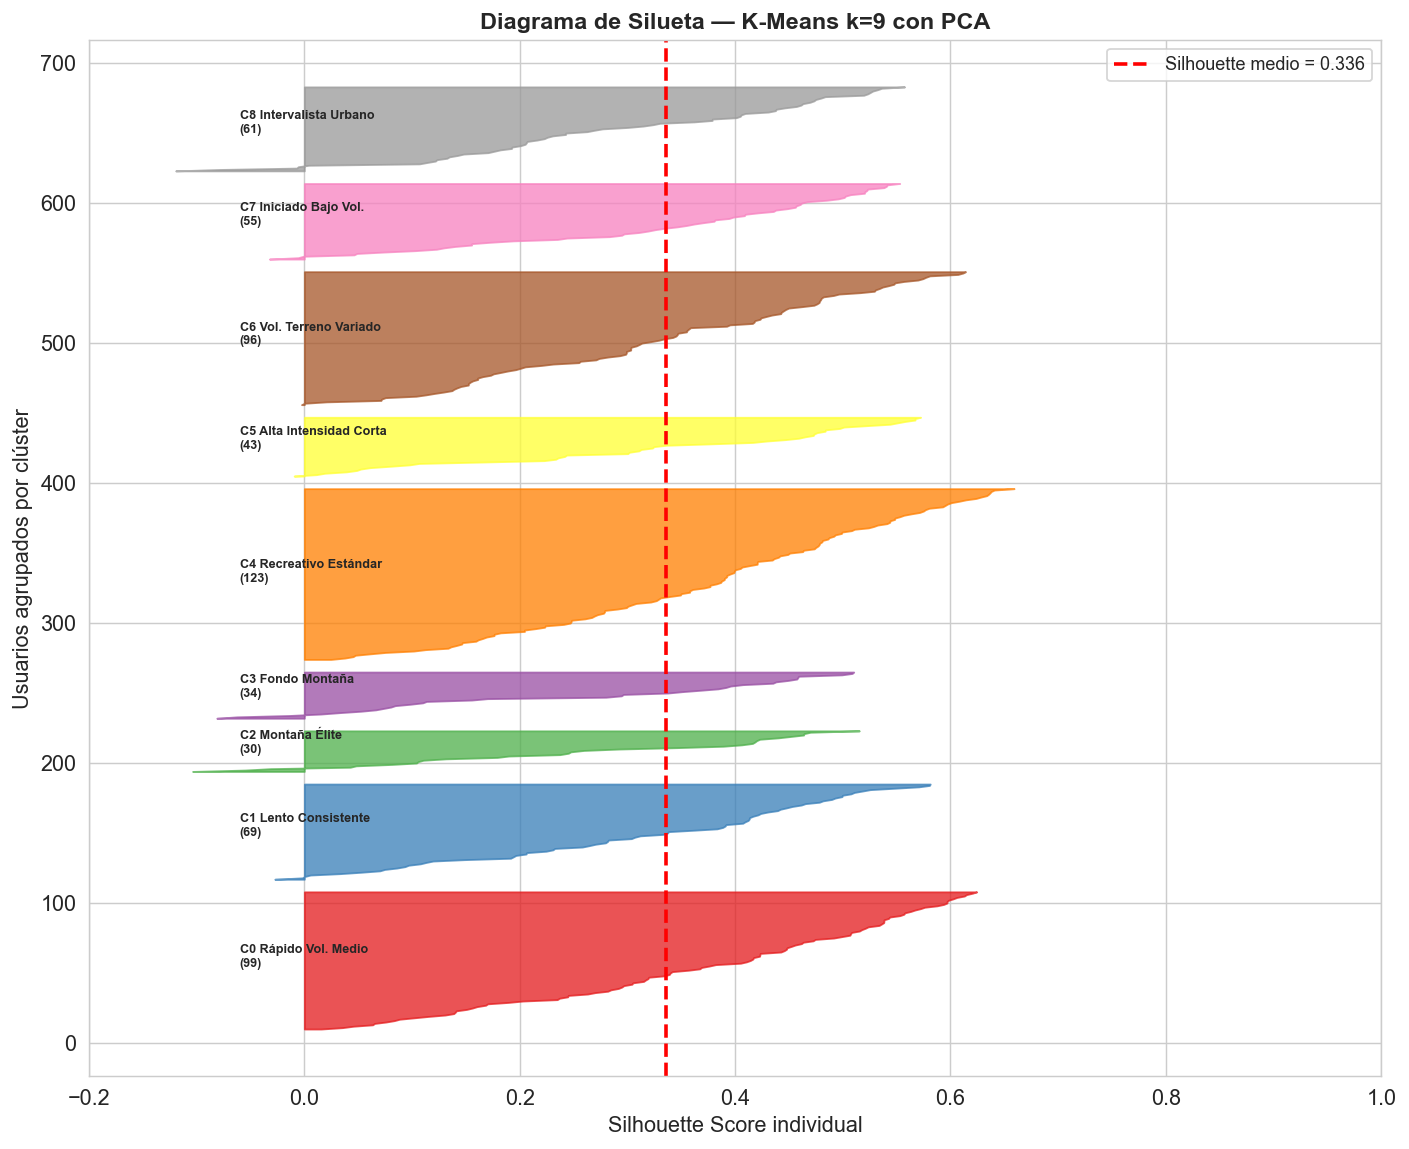

✅ silhouette_diagram.png guardado


In [ ]:
# ── 8.1 Diagrama de Silueta ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))
sample_sil = silhouette_samples(X_pca, labels_final)
y_lower    = 10

for i in range(BEST_K):
    vals    = np.sort(sample_sil[labels_final == i])
    size    = len(vals)
    y_upper = y_lower + size

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=colors_9[i],
                     edgecolor=colors_9[i], alpha=0.75)
    ax.text(-0.06, y_lower + 0.45 * size,
            f"C{i} {CLUSTER_NAMES[i]}\n({size})",
            fontsize=7, fontweight="bold")
    y_lower = y_upper + 8

ax.axvline(sil_final, color="red", linestyle="--", linewidth=2,
           label=f"Silhouette medio = {sil_final:.3f}")
ax.set_xlabel("Silhouette Score individual")
ax.set_ylabel("Usuarios agrupados por cluster")
ax.set_title(f"Diagrama de Silueta — K-Means k={BEST_K} con PCA",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim([-0.2, 1])
plt.tight_layout()
plt.savefig("silhouette_diagram.png", bbox_inches="tight", dpi=130)
plt.show()
print("silhouette_diagram.png guardado")

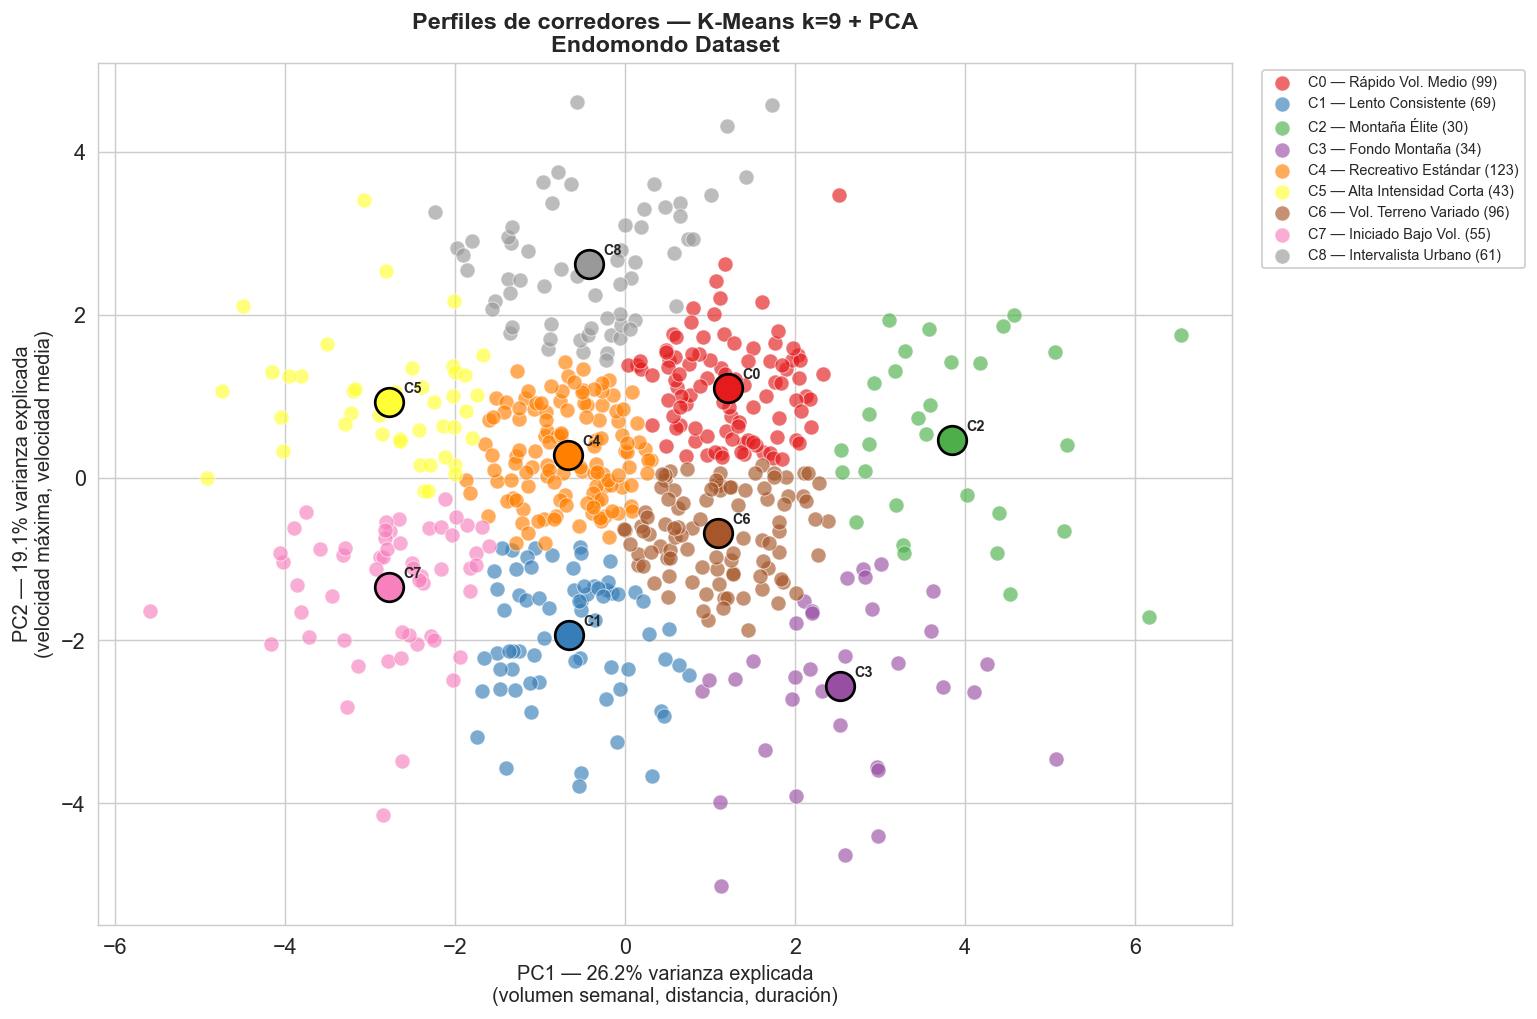

✅ pca_clusters.png guardado


In [ ]:
# ── 8.2 Proyeccion PCA (2D) ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

for i in range(BEST_K):
    mask = labels_final == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[colors_9[i]],
               label=f"C{i} — {CLUSTER_NAMES[i]} ({mask.sum()})",
               alpha=0.65, s=70,
               edgecolors="white", linewidths=0.5)

# Centroides
centroids = km_final.cluster_centers_
for i, c in enumerate(centroids):
    ax.scatter(c[0], c[1], c=[colors_9[i]],
               marker="o", s=250, zorder=5,
               edgecolors="black", linewidths=1.5)
    ax.annotate(f"C{i}", (c[0], c[1]),
                textcoords="offset points",
                xytext=(8, 5), fontsize=8, fontweight="bold")

var = pca.explained_variance_ratio_
ax.set_xlabel(f"PC1 — {var[0]*100:.1f}% varianza explicada\n"
              f"(volumen semanal, distancia, duracion)",
              fontsize=11)
ax.set_ylabel(f"PC2 — {var[1]*100:.1f}% varianza explicada\n"
              f"(velocidad maxima, velocidad media)",
              fontsize=11)
ax.set_title("Perfiles de corredores — K-Means k=9 + PCA\nEndomondo Dataset",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=8, framealpha=0.9,
          bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("pca_clusters.png", bbox_inches="tight", dpi=130)
plt.show()
print("pca_clusters.png guardado")

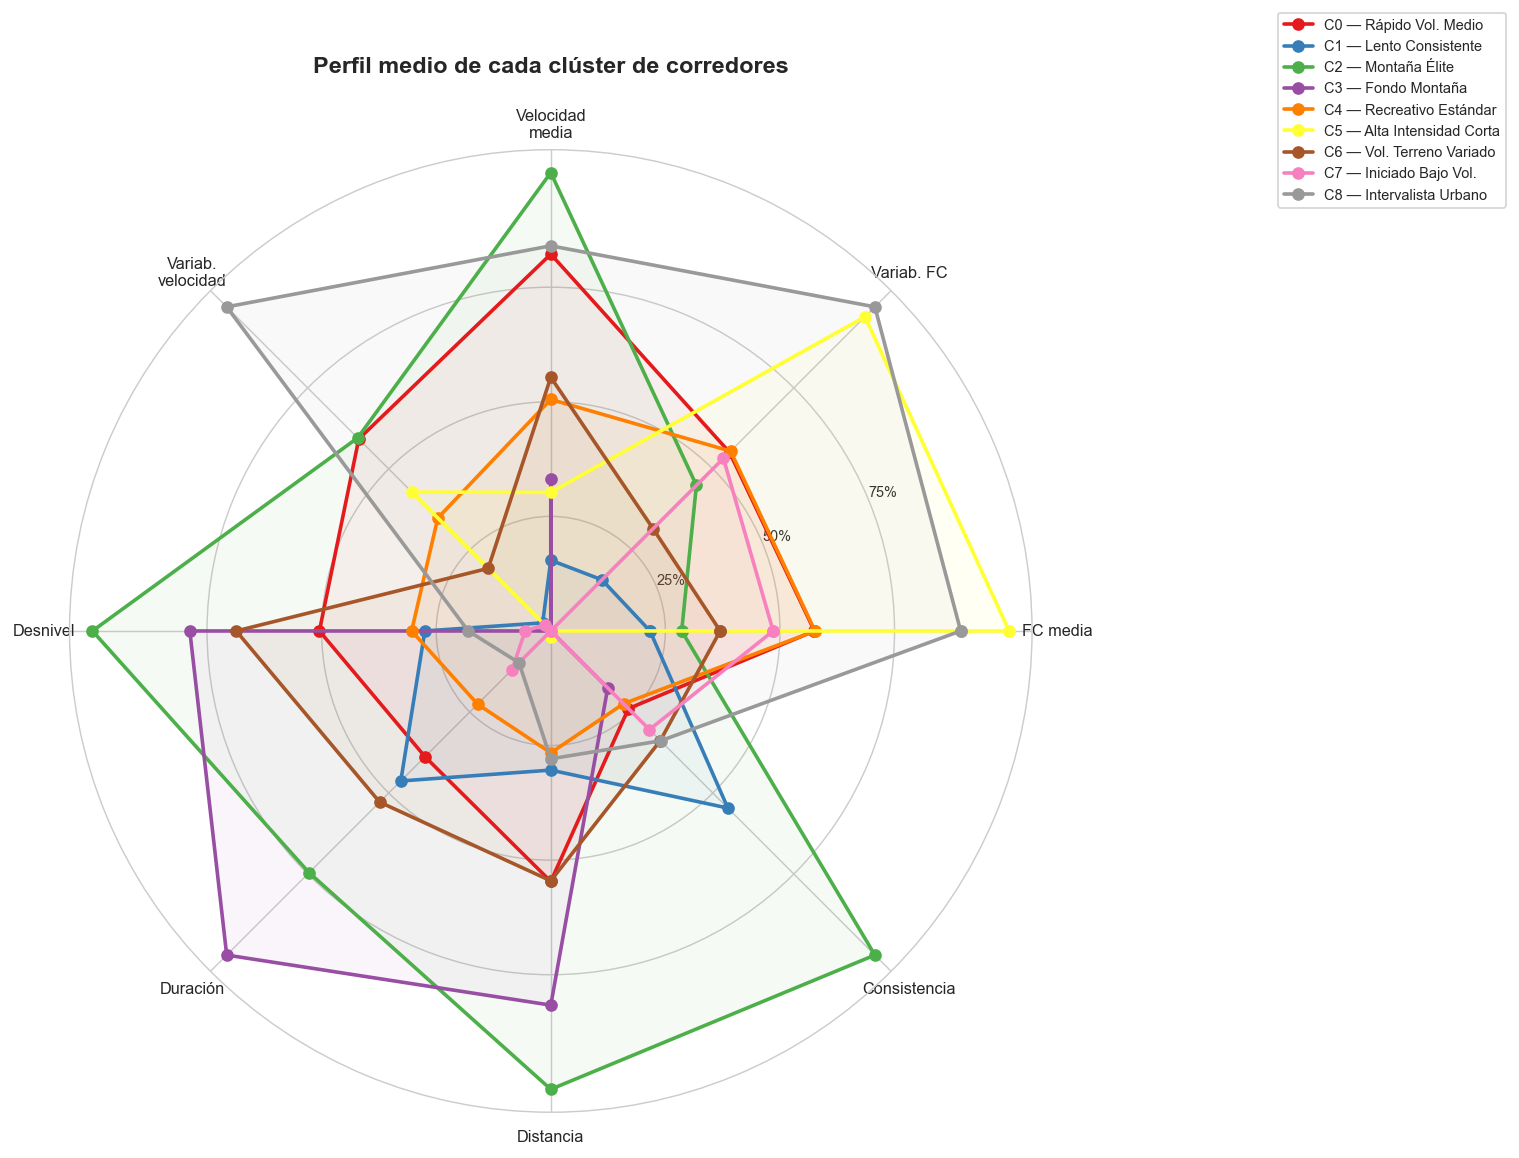

✅ cluster_radar.png guardado


In [ ]:
# ── 8.3 Grafico Radar ─────────────────────────────────────────────────────
# Usamos las 8 features mas interpretables para el radar
# (excluimos weekly_km y hr_speed_ratio por ser derivadas)
radar_features = [
    "hr_mean_avg", "hr_std_avg", "speed_mean_avg",
    "speed_std_avg", "elevation_avg", "duration_avg",
    "distance_avg", "speed_consistency",
]

cluster_stats_radar = df_result.groupby("cluster")[radar_features].mean()
df_norm = (
    (cluster_stats_radar - cluster_stats_radar.min()) /
    (cluster_stats_radar.max() - cluster_stats_radar.min() + 1e-9)
)

n_vars = len(radar_features)
angles = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(11, 9), subplot_kw=dict(polar=True))

for i, (c_id, row) in enumerate(df_norm.iterrows()):
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, "o-", linewidth=2,
            color=colors_9[i],
            label=f"C{c_id} — {CLUSTER_NAMES[c_id]}")
    ax.fill(angles, vals, alpha=0.05, color=colors_9[i])

labels_radar = [
    "FC media", "Variab. FC", "Velocidad\nmedia",
    "Variab.\nvelocidad", "Desnivel", "Duracion",
    "Distancia", "Consistencia"
]
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, size=9)
ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels(["25%", "50%", "75%"], size=8)
ax.set_title("Perfil medio de cada cluster de corredores",
             size=13, pad=20, fontweight="bold")
ax.legend(loc="upper right",
          bbox_to_anchor=(1.5, 1.15), fontsize=8)
plt.tight_layout()
plt.savefig("cluster_radar.png", bbox_inches="tight", dpi=130)
plt.show()
print("cluster_radar.png guardado")

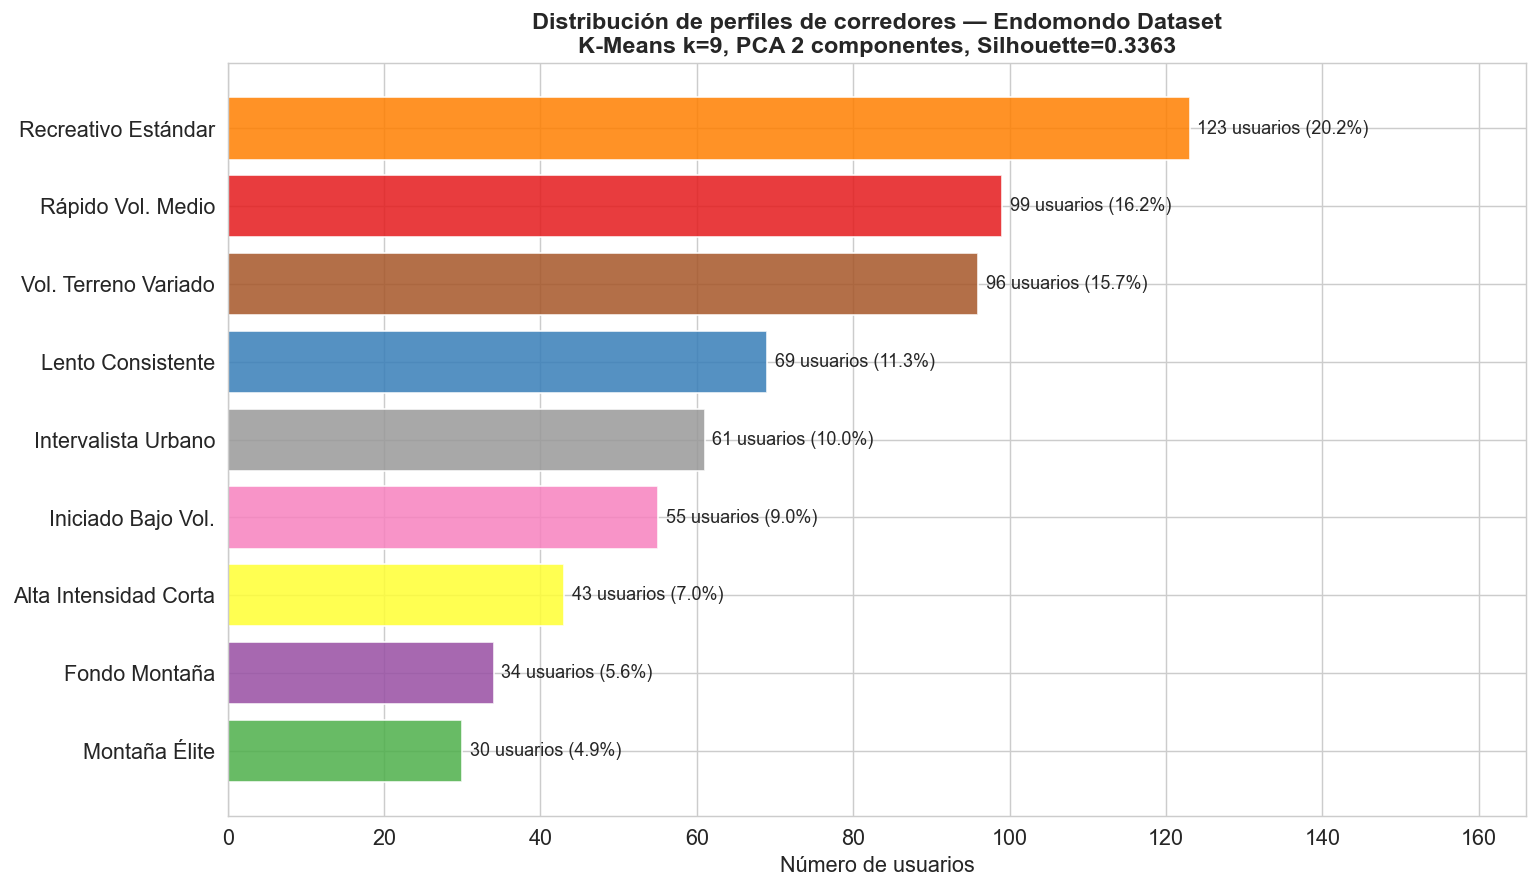

✅ distribucion_perfiles.png guardado


In [ ]:
# ── 8.5 Distribucion final de perfiles ────────────────────────────────────
perfil_counts = df_result["perfil"].value_counts().sort_values(ascending=True)
colors_bar    = [colors_9[i] for i in
                 [list(CLUSTER_NAMES.values()).index(p)
                  for p in perfil_counts.index]]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(perfil_counts.index, perfil_counts.values,
               color=colors_bar, edgecolor="white", alpha=0.85)

for bar, val in zip(bars, perfil_counts.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{val} usuarios ({val/len(df_result)*100:.1f}%)",
            va="center", fontsize=10)

ax.set_xlabel("Numero de usuarios")
ax.set_title("Distribucion de perfiles de corredores — Endomondo Dataset\n"
             f"K-Means k=9, PCA 2 componentes, Silhouette={sil_final:.4f}",
             fontsize=13, fontweight="bold")
ax.set_xlim(0, perfil_counts.max() * 1.35)
plt.tight_layout()
plt.savefig("distribucion_perfiles.png", bbox_inches="tight", dpi=130)
plt.show()
print("distribucion_perfiles.png guardado")

In [ ]:
# ── Seleccion de eps: K-Distance Graph ───────────────────────────────────
#
# Para elegir el parametro eps de DBSCAN usamos el K-Distance Graph.
# Para cada punto calculamos la distancia a su k-esimo vecino mas cercano
# y los ordenamos. El "codo" de la curva indica el eps optimo:
# a partir de ese punto las distancias crecen bruscamente.
# Ref: Ester et al. (1996). KDD'96.

k = 6  # min_samples candidato

nbrs         = NearestNeighbors(n_neighbors=k).fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)
distances    = np.sort(distances[:, k - 1])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(distances, linewidth=1.5, color="#2A9D8F")
ax.axhline(y=0.4, color="red", linestyle="--", linewidth=1.5, label="eps=0.4")
ax.set_xlabel("Puntos ordenados")
ax.set_ylabel(f"Distancia al {k}-esimo vecino")
ax.set_title("K-Distance Graph — seleccion de eps para DBSCAN",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("kdistance_graph.png", bbox_inches="tight", dpi=130)
plt.show()
print("✅ kdistance_graph.png guardado")


In [ ]:
# ── Busqueda de hiperparametros DBSCAN (eps × min_samples) ───────────────
# Rango de eps informado por el k-distance graph de la celda anterior.

eps_values         = np.arange(0.2, 0.8, 0.05)
min_samples_values = range(3, 12)

results = []

for eps, min_s in product(eps_values, min_samples_values):
    labels      = DBSCAN(eps=eps, min_samples=min_s).fit_predict(X_pca)
    n_clusters  = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_pct = (labels == -1).sum() / len(labels)

    if n_clusters < 2 or n_clusters > 8 or n_noise_pct > 0.30:
        continue

    sil = silhouette_score(X_pca[labels != -1], labels[labels != -1])
    results.append({
        "eps":         round(eps, 2),
        "min_samples": min_s,
        "n_clusters":  n_clusters,
        "noise_pct":   round(n_noise_pct * 100, 1),
        "silhouette":  round(sil, 4),
    })

df_results = pd.DataFrame(results).sort_values("silhouette", ascending=False)
print(df_results.head(10).to_string(index=False))

# ── Heatmap silhouette ────────────────────────────────────────────────────
pivot = df_results.pivot_table(
    index="min_samples", columns="eps", values="silhouette", aggfunc="max"
)
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu",
            linewidths=0.5, ax=ax)
ax.set_title("Silhouette Score — DBSCAN (eps × min_samples)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("dbscan_hiperparametros.png", bbox_inches="tight", dpi=130)
plt.show()
print("✅ dbscan_hiperparametros.png guardado")


In [ ]:
# ── DBSCAN optimo: eps=0.7, min_samples=4 ────────────────────────────────

db_final  = DBSCAN(eps=0.7, min_samples=4)
labels_db = db_final.fit_predict(X_pca)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db    = (labels_db == -1).sum()
mask_valid    = labels_db != -1
sil_db        = silhouette_score(X_pca[mask_valid], labels_db[mask_valid])

print(f"✅ DBSCAN optimo ejecutado.")
print(f"   eps              : 0.7")
print(f"   min_samples      : 4")
print(f"   Clusters         : {n_clusters_db}")
print(f"   Ruido            : {n_noise_db} usuarios ({n_noise_db/len(labels_db)*100:.1f}%)")
print(f"   Silhouette Score : {sil_db:.4f}")
print(f"   Usuarios         : {len(labels_db)}")

# ── Construir DataFrame de resultados ─────────────────────────────────────
df_dbscan            = X_clean.copy()
df_dbscan["user_id"] = user_ids.values
df_dbscan["cluster"] = labels_db
df_dbscan["gender"]  = df_dbscan["user_id"].map(df_users.set_index("user_id")["gender"])

# ── Distribucion por cluster ───────────────────────────────────────────────
print(f"\nDistribucion de usuarios por cluster:")
dist_db = pd.Series(labels_db).value_counts().sort_index()
for c, n in dist_db.items():
    nombre = "RUIDO" if c == -1 else f"Cluster {c}"
    bar    = "█" * int(n / dist_db.max() * 30)
    print(f"  {nombre:12}: {n:3d} usuarios ({n/len(labels_db)*100:.1f}%)  {bar}")

# ── Diferencias respecto a la media global ────────────────────────────────
print(f"\n=== Diferencia entre clusteres DBSCAN (%) vs media global ===")
global_mean_db = df_dbscan[df_dbscan["cluster"] != -1][FEATURE_COLS].mean()

for c in range(n_clusters_db):
    subset       = df_dbscan[df_dbscan["cluster"] == c]
    cluster_mean = subset[FEATURE_COLS].mean()
    print(f"\n  Cluster {c} ({len(subset)} usuarios):")
    for feat in FEATURE_COLS:
        diff  = (cluster_mean[feat] - global_mean_db[feat]) / global_mean_db[feat] * 100
        arrow = "▲" if diff > 0 else "▼"
        print(f"    {arrow} {feat:<22}: {diff:+.1f}%")


In [ ]:
# ── 8.2 Proyeccion PCA (2D) — DBSCAN ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

clusters_db = sorted(set(labels_db))
colors_db   = plt.cm.Set1(np.linspace(0, 1, max(len(clusters_db), 2)))

for i, c in enumerate(clusters_db):
    mask   = labels_db == c
    label  = f"Ruido ({mask.sum()})" if c == -1 else f"C{c} ({mask.sum()})"
    color  = "lightgray" if c == -1 else colors_db[i]
    marker = "x" if c == -1 else "o"
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=label,
               alpha=0.65, s=70, marker=marker,
               edgecolors="white" if c != -1 else "none",
               linewidths=0.5)

# Centroides (excluir ruido)
for i, c in enumerate(clusters_db):
    if c == -1:
        continue
    mask   = labels_db == c
    cx, cy = X_pca[mask, 0].mean(), X_pca[mask, 1].mean()
    ax.scatter(cx, cy, c=[colors_db[i]],
               marker="o", s=250, zorder=5,
               edgecolors="black", linewidths=1.5)
    ax.annotate(f"C{c}", (cx, cy),
                textcoords="offset points",
                xytext=(8, 5), fontsize=8, fontweight="bold")

var = pca.explained_variance_ratio_
ax.set_xlabel(f"PC1 — {var[0]*100:.1f}% varianza explicada\n"
              f"(volumen semanal, distancia, duracion)",
              fontsize=11)
ax.set_ylabel(f"PC2 — {var[1]*100:.1f}% varianza explicada\n"
              f"(velocidad maxima, velocidad media)",
              fontsize=11)
ax.set_title(f"Perfiles de corredores — DBSCAN eps=0.7 min_s=4\nEndomondo Dataset",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=8, framealpha=0.9,
          bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("pca_clusters_dbscan.png", bbox_inches="tight", dpi=130)
plt.show()
print("✅ pca_clusters_dbscan.png guardado")


In [ ]:
# ── CLUSTERING JERÁRQUICO ─────────────────────────────────────────────────
#
# El clustering jerarquico construye una jerarquía de clusters de forma
# ascendente (aglomerativa), fusionando progresivamente los grupos mas
# similares hasta obtener un unico cluster que engloba todos los datos.
#
# El resultado se visualiza mediante un DENDROGRAMA que permite elegir
# el nivel de granularidad deseado cortando a distintas alturas.
#
# Usamos el metodo de Ward (1963) — minimiza la varianza intra-cluster
# en cada fusion, siendo el mas comparable con K-Means.
#
# Ref: Ward, J.H. (1963). Hierarchical grouping to optimize an objective
#      function. Journal of the American Statistical Association, 58, 236-244.

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance  import pdist

# ── Paso 1: Calcular la matriz de linkage ─────────────────────────────────
Z = linkage(X_pca, method="ward")

print("✅ Matriz de linkage calculada (metodo Ward).")
print(f"   Usuarios: {X_pca.shape[0]}")
print(f"   Dimensiones PCA: {X_pca.shape[1]}")

✅ Matriz de linkage calculada (método Ward).
   Usuarios: 610
   Dimensiones PCA: 2


In [ ]:
# ── Paso 2: Dendrograma completo ──────────────────────────────────────────
# El dendrograma muestra visualmente en que punto se fusionan los grupos.
# Las fusiones a mayor altura (eje Y) indican grupos mas distintos entre sí.
# El corte optimo esta donde hay un salto grande en la altura de fusion.

fig, ax = plt.subplots(figsize=(14, 6))

dendrogram(
    Z,
    ax=ax,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True,
    color_threshold=0,
)

ax.set_title("Dendrograma — Clustering Jerarquico (metodo Ward)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Usuarios (numero entre parentesis = tamaño del grupo)")
ax.set_ylabel("Distancia de fusion (Ward)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("dendrograma.png", bbox_inches="tight", dpi=130)
plt.show()
print("✅ dendrograma.png guardado")
print("\n💡 Busca el salto mas grande en el eje Y.")
print("   Ese punto indica el numero natural de clusters.")


In [ ]:
# ── Paso 3: Silhouette para distintos k ───────────────────────────────────
# Cortamos el dendrograma a distintas alturas y evaluamos la calidad
# con Silhouette Score — igual que hicimos con K-Means.

print("=== Silhouette Score por número de clusters (Jerarquico Ward) ===\n")
print(f"{'k':>4} | {'Silhouette':>12}")
print("-" * 20)

sil_hier   = []
k_range_h  = range(2, 11)

for k in k_range_h:
    labels_h = fcluster(Z, k, criterion="maxclust")
    sil      = silhouette_score(X_pca, labels_h)
    sil_hier.append(sil)
    print(f"{k:>4} | {sil:>12.4f}")

best_k_hier = list(k_range_h)[sil_hier.index(max(sil_hier))]
print(f"\n✅ k optimo Jerarquico : {best_k_hier}")
print(f"   Silhouette Score   : {max(sil_hier):.4f}")

=== Silhouette Score por número de clusters (Jerárquico Ward) ===

   k |   Silhouette
--------------------
   2 |       0.2823
   3 |       0.2990
   4 |       0.2872
   5 |       0.2729
   6 |       0.2822
   7 |       0.2896
   8 |       0.2957
   9 |       0.3004
  10 |       0.2852

✅ k óptimo Jerárquico : 9
   Silhouette Score   : 0.3004


In [ ]:
# ── Paso 4: Modelo final jerarquico ──────────────────────────────────────

labels_hier_eval = fcluster(Z, best_k_hier, criterion="maxclust") - 1
n_clusters_hier  = len(set(labels_hier_eval))
sil_hier_final   = silhouette_score(X_pca, labels_hier_eval)

print(f"✅ Clustering Jerarquico Ward — modelo final.")
print(f"   Metodo           : Ward")
print(f"   k                : {n_clusters_hier}")
print(f"   Silhouette Score : {sil_hier_final:.4f}")
print(f"   Usuarios         : {len(labels_hier_eval)}")

print(f"\nDistribucion de usuarios por clúster:")
dist_hier = pd.Series(labels_hier_eval).value_counts().sort_index()
for c, n in dist_hier.items():
    bar = "█" * int(n / dist_hier.max() * 30)
    print(f"  Clúster {c}: {n:3d} usuarios "
          f"({n/len(labels_hier_eval)*100:.1f}%)  {bar}")


In [ ]:
# ── Bloque Jerarquico: perfil de clústeres ────────────────────────────────

df_hier            = X_clean.copy()
df_hier["user_id"] = user_ids.values
df_hier["cluster"] = labels_hier_eval
df_hier["gender"]  = df_hier["user_id"].map(df_users.set_index("user_id")["gender"])

print(f"✅ Clustering Jerarquico Ward.")
print(f"   k                  : {best_k_hier}")
print(f"   Silhouette Score   : {sil_hier_final:.4f}")
print(f"   Usuarios           : {len(X_pca)}")

print(f"\n=== Perfil medio de cada clúster ===")
hier_stats = df_hier.groupby("cluster")[FEATURE_COLS].mean().round(2)
hier_stats["n_usuarios"] = df_hier.groupby("cluster").size()
display(hier_stats)

print("\n=== Diferencia de cada clúster respecto a la media global (%) ===")
global_mean_h = df_hier[FEATURE_COLS].mean()

for c in range(best_k_hier):
    subset       = df_hier[df_hier["cluster"] == c]
    cluster_mean = subset[FEATURE_COLS].mean()
    print(f"\n  Clúster {c} ({len(subset)} usuarios):")
    for feat in FEATURE_COLS:
        diff  = (cluster_mean[feat] - global_mean_h[feat]) / global_mean_h[feat] * 100
        arrow = "▲" if diff > 0 else "▼"
        print(f"    {arrow} {feat:<22}: {diff:+.1f}%")


In [ ]:
CLUSTER_NAMES_HIER = {
    0: "Iniciado Bajo Vol.",
    1: "Iniciado Alta Velocidad",
    2: "Lento Consistente",
    3: "Recreativo Estandar",
    4: "Montaña Élite",
    5: "Fondo Montaña",
    6: "Vol. Terreno Variado",
    7: "Intervalista Urbano",
    8: "Alta Intensidad Corta",
}


In [ ]:
# ── Diagrama de Silueta — Jerarquico Ward ────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
sample_sil_h = silhouette_samples(X_pca, labels_hier_eval)
y_lower      = 10

for i in range(best_k_hier):
    vals    = np.sort(sample_sil_h[labels_hier_eval == i])
    size    = len(vals)
    y_upper = y_lower + size

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=colors_9[i],
                     edgecolor=colors_9[i], alpha=0.75)
    ax.text(-0.06, y_lower + 0.45 * size,
            f"C{i} {CLUSTER_NAMES_HIER[i]}\n({size})",
            fontsize=7, fontweight="bold")
    y_lower = y_upper + 8

ax.axvline(sil_hier_final, color="red", linestyle="--", linewidth=2,
           label=f"Silhouette medio = {sil_hier_final:.3f}")
ax.set_xlabel("Silhouette Score individual")
ax.set_ylabel("Usuarios agrupados por clúster")
ax.set_title(f"Diagrama de Silueta — Jerarquico Ward k={best_k_hier} con PCA",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim([-0.2, 1])
plt.tight_layout()
plt.savefig("hier_silhouette_diagram.png", bbox_inches="tight", dpi=130)
plt.show()
print("✅ hier_silhouette_diagram.png guardado")


In [ ]:
# ── 8.2 Proyeccion PCA (2D) — Jerarquico Ward ────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

for i in range(best_k_hier):
    mask = labels_hier_eval == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[colors_9[i]],
               label=f"C{i} — {CLUSTER_NAMES_HIER[i]} ({mask.sum()})",
               alpha=0.65, s=70,
               edgecolors="white", linewidths=0.5)

# Centroides
centroids_hier = np.array([
    X_pca[labels_hier_eval == i].mean(axis=0) for i in range(best_k_hier)
])
for i, c in enumerate(centroids_hier):
    ax.scatter(c[0], c[1], c=[colors_9[i]],
               marker="o", s=250, zorder=5,
               edgecolors="black", linewidths=1.5)
    ax.annotate(f"C{i}", (c[0], c[1]),
                textcoords="offset points",
                xytext=(8, 5), fontsize=8, fontweight="bold")

var = pca.explained_variance_ratio_
ax.set_xlabel(f"PC1 — {var[0]*100:.1f}% varianza explicada\n"
              f"(volumen semanal, distancia, duracion)",
              fontsize=11)
ax.set_ylabel(f"PC2 — {var[1]*100:.1f}% varianza explicada\n"
              f"(velocidad maxima, velocidad media)",
              fontsize=11)
ax.set_title(f"Perfiles de corredores — Jerarquico Ward k={best_k_hier} + PCA\n"
             f"Endomondo Dataset",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=8, framealpha=0.9,
          bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("hier_clusters.png", bbox_inches="tight", dpi=130)
plt.show()
print("✅ hier_clusters.png guardado")


In [ ]:
# ── Comparativa visual de los tres algoritmos ─────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── K-Means ───────────────────────────────────────────────────────────────
for i in range(BEST_K):
    mask = labels_final == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[colors_9[i]],
                    label=f"Clúster {i} ({mask.sum()})",
                    alpha=0.7, s=60)
axes[0].set_title(f"K-Means k={BEST_K}\nSilhouette={sil_final:.4f}",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(fontsize=9)

# ── DBSCAN ────────────────────────────────────────────────────────────────
colors_db_map = {-1: "lightgray", 0: "#E76F51", 1: "#2A9D8F"}
for c in sorted(set(labels_db)):
    mask  = labels_db == c
    color = colors_db_map.get(c, "#264653")
    label = f"Ruido ({mask.sum()})" if c == -1 else f"Clúster {c} ({mask.sum()})"
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=label, alpha=0.7, s=60)
axes[1].set_title(f"DBSCAN eps=0.70 min_s=4\nSilhouette={sil_db:.4f}",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(fontsize=9)

# ── Jerarquico ────────────────────────────────────────────────────────────
colors_hier = plt.cm.Set2(np.linspace(0, 1, best_k_hier))
for i in range(best_k_hier):
    mask = labels_hier_eval == i
    axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[colors_hier[i]],
                    label=f"Clúster {i} ({mask.sum()})",
                    alpha=0.7, s=60)
axes[2].set_title(f"Jerarquico Ward k={best_k_hier}\n"
                  f"Silhouette={max(sil_hier):.4f}",
                  fontsize=11, fontweight="bold")
axes[2].set_xlabel("PC1")
axes[2].set_ylabel("PC2")
axes[2].legend(fontsize=9)

plt.suptitle("Comparativa de algoritmos de clustering — Endomondo Dataset",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("comparativa_algoritmos.png", bbox_inches="tight", dpi=130)
plt.show()
print("✅ comparativa_algoritmos.png guardado")


In [ ]:
# ── EVALUACIÓN COMPARATIVA DE LOS 3 ALGORITMOS ────────────────────────────
#
# Evaluamos los tres algoritmos con metricas internas de clustering.
# En clustering no supervisado no hay etiquetas reales para comparar,
# por lo que usamos metricas que evalúan la calidad de los grupos
# basandose únicamente en los datos.
#
# Ref: Davies & Bouldin (1979), Calinski & Harabasz (1974), Rousseeuw (1987)

# ── Preparar etiquetas de cada algoritmo ──────────────────────────────────
labels_km        = labels_final
labels_hier_eval = fcluster(Z, best_k_hier, criterion="maxclust") - 1


def evaluate_clustering(X, labels, name):
    '''Calcula las metricas de evaluacion para un conjunto de etiquetas.
    Para DBSCAN excluye el ruido (-1) del calculo de metricas internas.'''
    mask       = labels != -1
    X_valid    = X[mask]
    l_valid    = labels[mask]
    n_clusters = len(set(l_valid))
    n_noise    = (labels == -1).sum()
    cobertura  = mask.sum() / len(labels) * 100

    if n_clusters < 2:
        return {
            "Algoritmo":           name,
            "k":                   n_clusters,
            "Cobertura%":          round(cobertura, 1),
            "Silhouette ↑":        None,
            "Davies-Bouldin ↓":    None,
            "Calinski-Harabasz ↑": None,
            "Inercia ↓":           None,
            "Usuarios ruido":      n_noise,
        }

    sil = silhouette_score(X_valid, l_valid)
    db  = davies_bouldin_score(X_valid, l_valid)
    ch  = calinski_harabasz_score(X_valid, l_valid)

    inercia = 0
    for c in set(l_valid):
        puntos   = X_valid[l_valid == c]
        centroid = puntos.mean(axis=0)
        inercia += ((puntos - centroid) ** 2).sum()

    return {
        "Algoritmo":           name,
        "k":                   n_clusters,
        "Cobertura%":          round(cobertura, 1),
        "Silhouette ↑":        round(sil, 4),
        "Davies-Bouldin ↓":    round(db, 4),
        "Calinski-Harabasz ↑": round(ch, 2),
        "Inercia ↓":           round(inercia, 1),
        "Usuarios ruido":      n_noise,
    }


# ── Evaluar los 3 algoritmos ───────────────────────────────────────────────
resultados = [
    evaluate_clustering(X_pca, labels_km,        "K-Means"),
    evaluate_clustering(X_pca, labels_db,         "DBSCAN"),
    evaluate_clustering(X_pca, labels_hier_eval,  "Jerarquico Ward"),
]
df_eval = pd.DataFrame(resultados).set_index("Algoritmo")

print("=" * 70)
print("  EVALUACIÓN COMPARATIVA DE ALGORITMOS DE CLUSTERING")
print(f"  Dataset: Endomondo | Usuarios: {len(X_pca)} | Espacio: PCA 2 componentes")
print("=" * 70)
display(df_eval)

# ── Ganador por metrica ────────────────────────────────────────────────────
print("\n=== Ganador por metrica ===\n")
metricas_eval = {
    "Silhouette ↑":        "max",
    "Davies-Bouldin ↓":    "min",
    "Calinski-Harabasz ↑": "max",
    "Inercia ↓":           "min",
    "Cobertura%":          "max",
}
for metrica, criterio in metricas_eval.items():
    col     = df_eval[metrica].dropna()
    ganador = col.idxmax() if criterio == "max" else col.idxmin()
    valor   = col.max()    if criterio == "max" else col.min()
    print(f"  {metrica:<25} → 🏆 {ganador} ({valor})")

# ── Radar de metricas comparativas ────────────────────────────────────────
df_radar = df_eval[["Silhouette ↑", "Davies-Bouldin ↓",
                     "Calinski-Harabasz ↑", "Cobertura%"]].copy()

df_norm_eval = df_radar.copy()
for col in df_radar.columns:
    min_v = df_radar[col].min()
    max_v = df_radar[col].max()
    if "↓" in col:
        df_norm_eval[col] = 1 - (df_radar[col] - min_v) / (max_v - min_v + 1e-9)
    else:
        df_norm_eval[col] = (df_radar[col] - min_v) / (max_v - min_v + 1e-9)

radar_labels = ["Silhouette", "Davies-Bouldin\n(inv.)",
                "Calinski-\nHarabasz", "Cobertura"]
n_vars  = len(radar_labels)
angles  = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 7), subplot_kw=dict(polar=True))
colors_radar = ["#E76F51", "#2A9D8F", "#E9C46A"]

for i, (algo, row) in enumerate(df_norm_eval.iterrows()):
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, "o-", linewidth=2,
            color=colors_radar[i], label=algo)
    ax.fill(angles, vals, alpha=0.08, color=colors_radar[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, size=9)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], size=7)
ax.set_title("Comparativa de algoritmos — radar de metricas\n"
             "(valores normalizados, mayor = mejor)",
             size=12, pad=20, fontweight="bold")
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig("radar_metricas_comparativa.png", bbox_inches="tight", dpi=130)
plt.show()
print("✅ radar_metricas_comparativa.png guardado")


In [ ]:
# ── VISUALIZACIONES COMPARATIVAS DE LOS 3 ALGORITMOS ─────────────────────
#
# 6 visualizaciones complementarias para el TFM:
#   1. Barras de metricas comparativas
#   2. Distribucion de tamaños de cluster
#   3. Mapas de calor de perfiles medios
#   4. Diagrama de silueta comparativo (3 subplots)
#   5. Scatter PCA con centroides
#   6. Tabla resumen exportable

# ── Preparar datos comunes ────────────────────────────────────────────────
algos = {
    "K-Means":         labels_km,
    "DBSCAN":          labels_db,
    "Jerarquico Ward": labels_hier_eval,
}
colors_eval = ["#E76F51", "#2A9D8F", "#E9C46A"]

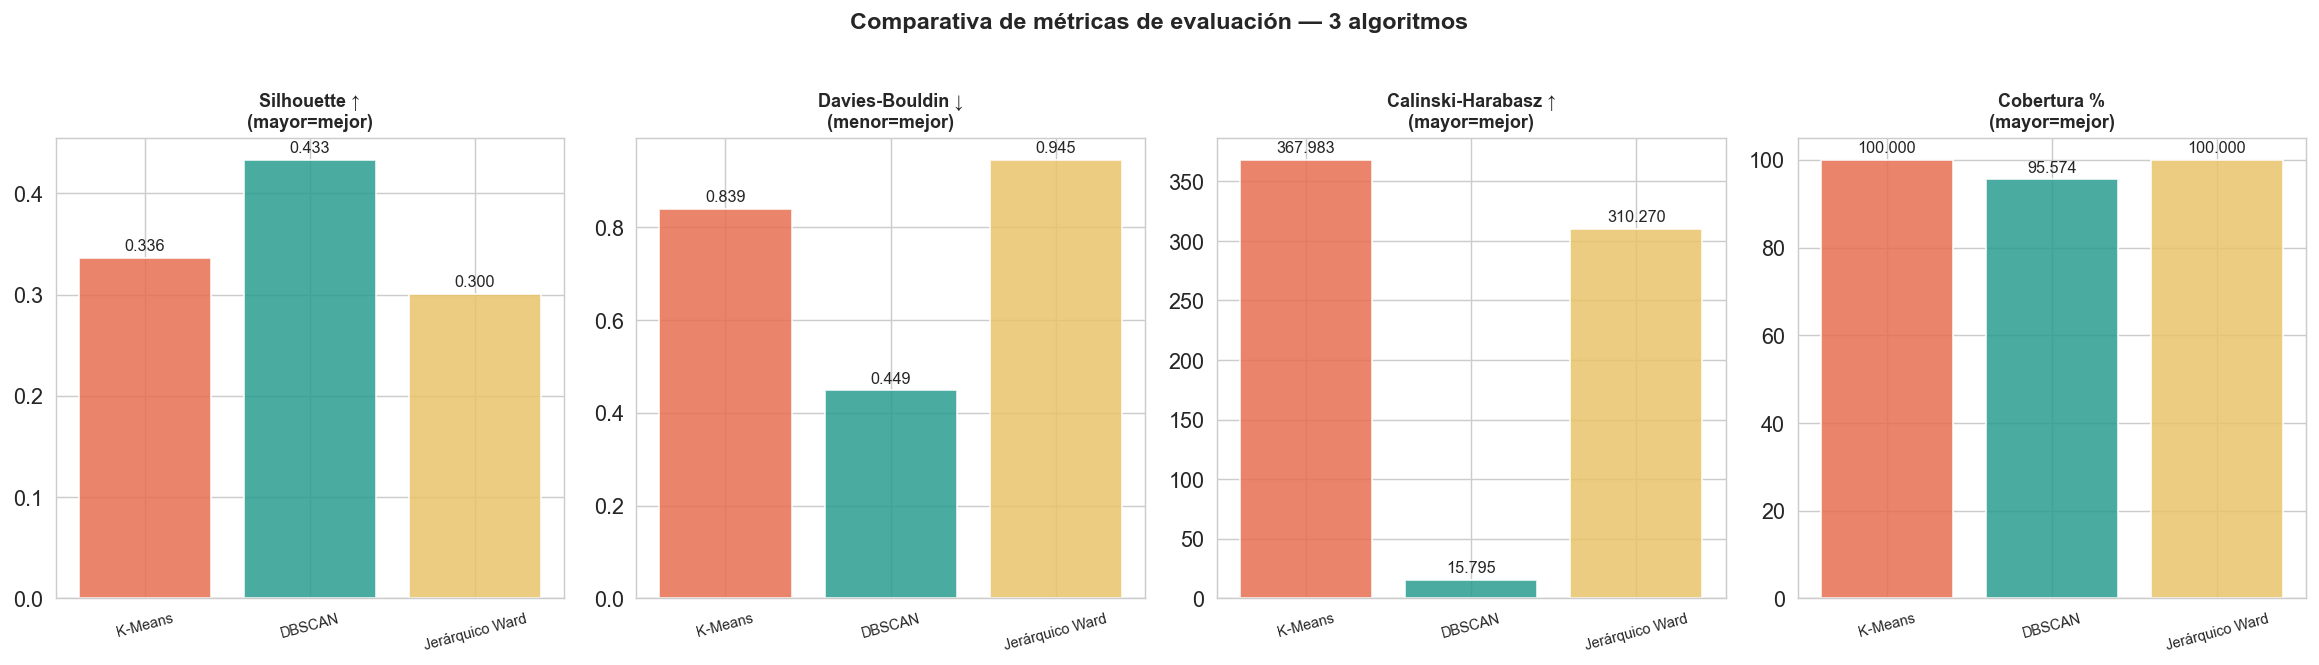

✅ viz1_metricas_barras.png guardado


In [ ]:
# ── VIZ 1: Barras de metricas comparativas ────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

metricas_bar = {
    "Silhouette ↑\n(mayor=mejor)":        
        [silhouette_score(X_pca[labels_km != -1],        labels_km[labels_km != -1]),
         silhouette_score(X_pca[labels_db != -1],   labels_db[labels_db != -1]),
         silhouette_score(X_pca[labels_hier_eval != -1], labels_hier_eval[labels_hier_eval != -1])],

    "Davies-Bouldin ↓\n(menor=mejor)":    
        [davies_bouldin_score(X_pca[labels_km != -1],        labels_km[labels_km != -1]),
         davies_bouldin_score(X_pca[labels_db != -1],   labels_db[labels_db != -1]),
         davies_bouldin_score(X_pca[labels_hier_eval != -1], labels_hier_eval[labels_hier_eval != -1])],

    "Calinski-Harabasz ↑\n(mayor=mejor)": 
        [calinski_harabasz_score(X_pca[labels_km != -1],        labels_km[labels_km != -1]),
         calinski_harabasz_score(X_pca[labels_db != -1],   labels_db[labels_db != -1]),
         calinski_harabasz_score(X_pca[labels_hier_eval != -1], labels_hier_eval[labels_hier_eval != -1])],

    "Cobertura %\n(mayor=mejor)":         
        [(labels_km != -1).sum()        / len(labels_km)        * 100,
         (labels_db != -1).sum()   / len(labels_db)   * 100,
         (labels_hier_eval != -1).sum() / len(labels_hier_eval) * 100],
}

for ax, (metrica, valores) in zip(axes, metricas_bar.items()):
    bars = ax.bar(list(algos.keys()), valores,
                  color=colors_eval, edgecolor="white", alpha=0.85)
    ax.set_title(metrica, fontsize=10, fontweight="bold")
    ax.set_xticklabels(list(algos.keys()), rotation=15, fontsize=8)

    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(valores)*0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Comparativa de metricas de evaluacion — 3 algoritmos",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("viz1_metricas_barras.png", bbox_inches="tight", dpi=130)
plt.show()
print("✅ viz1_metricas_barras.png guardado")

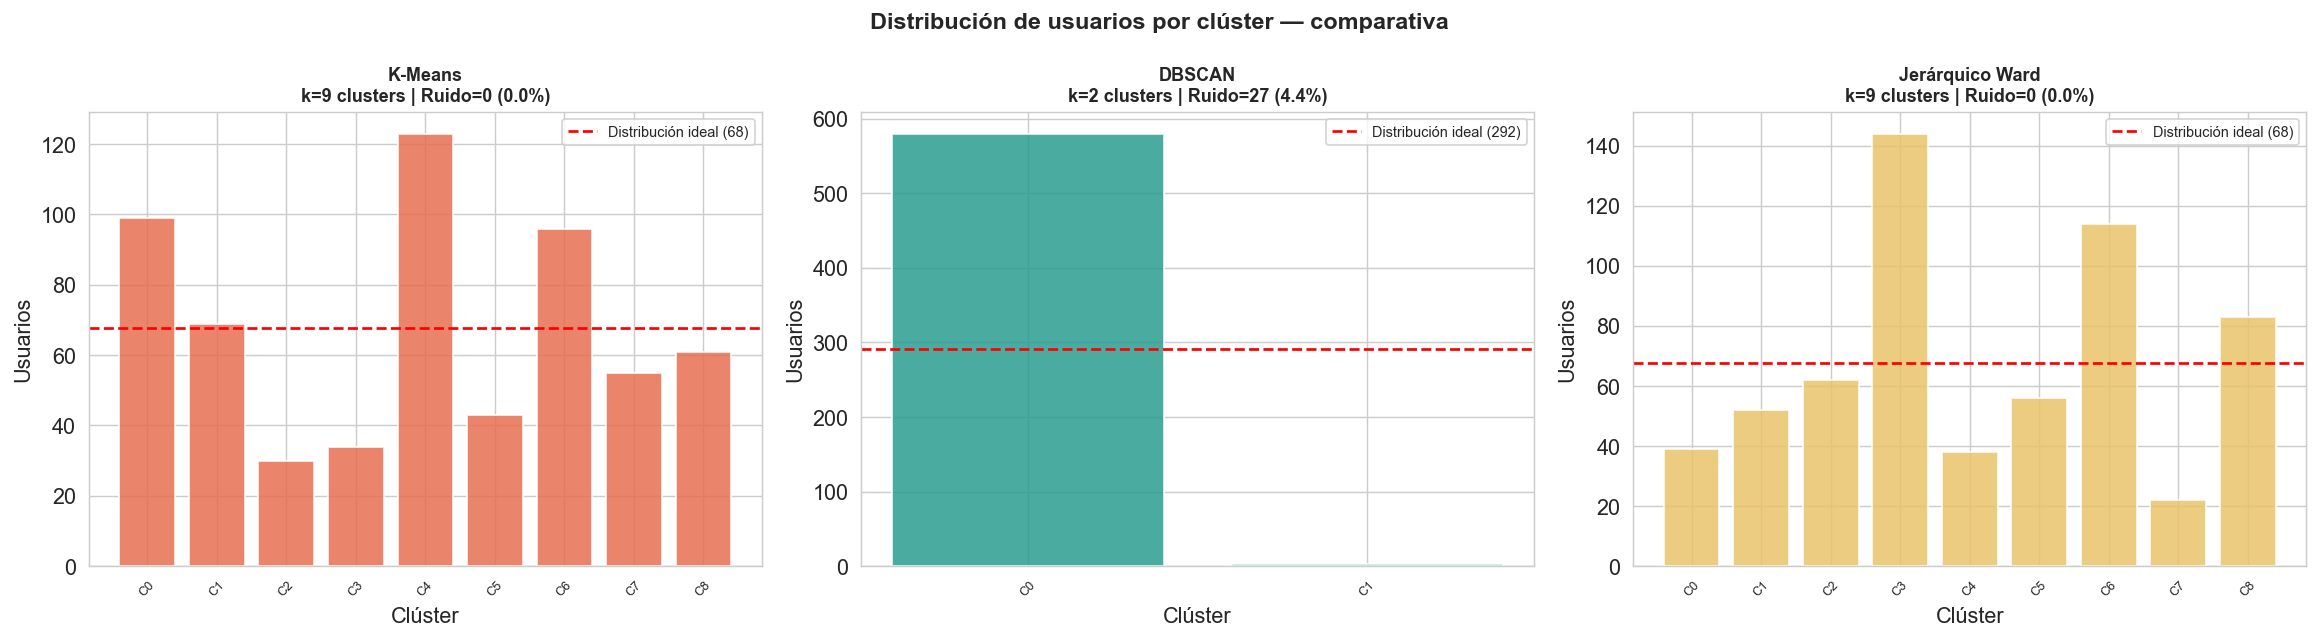

✅ viz2_distribucion_clusters.png guardado


In [ ]:
# ── VIZ 2: Distribucion de tamaños de cluster ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nombre, labels), color in zip(axes, algos.items(), colors_eval):
    # Contar usuarios por cluster (excluir ruido)
    counts = pd.Series(labels)
    counts_valid = counts[counts != -1].value_counts().sort_index()
    n_ruido = (counts == -1).sum()

    bars = ax.bar(range(len(counts_valid)), counts_valid.values,
                  color=color, edgecolor="white", alpha=0.85)

    # Línea de distribucion ideal (equitativa)
    total_valid = counts_valid.sum()
    ideal = total_valid / len(counts_valid)
    ax.axhline(ideal, color="red", linestyle="--", linewidth=1.5,
               label=f"Distribucion ideal ({ideal:.0f})")

    ax.set_title(f"{nombre}\n"
                 f"k={len(counts_valid)} clusters | "
                 f"Ruido={n_ruido} ({n_ruido/len(labels)*100:.1f}%)",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Clúster")
    ax.set_ylabel("Usuarios")
    ax.set_xticks(range(len(counts_valid)))
    ax.set_xticklabels([f"C{i}" for i in counts_valid.index],
                       fontsize=7, rotation=45)
    ax.legend(fontsize=8)

plt.suptitle("Distribucion de usuarios por clúster — comparativa",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("viz2_distribucion_clusters.png", bbox_inches="tight", dpi=130)
plt.show()
print("✅ viz2_distribucion_clusters.png guardado")

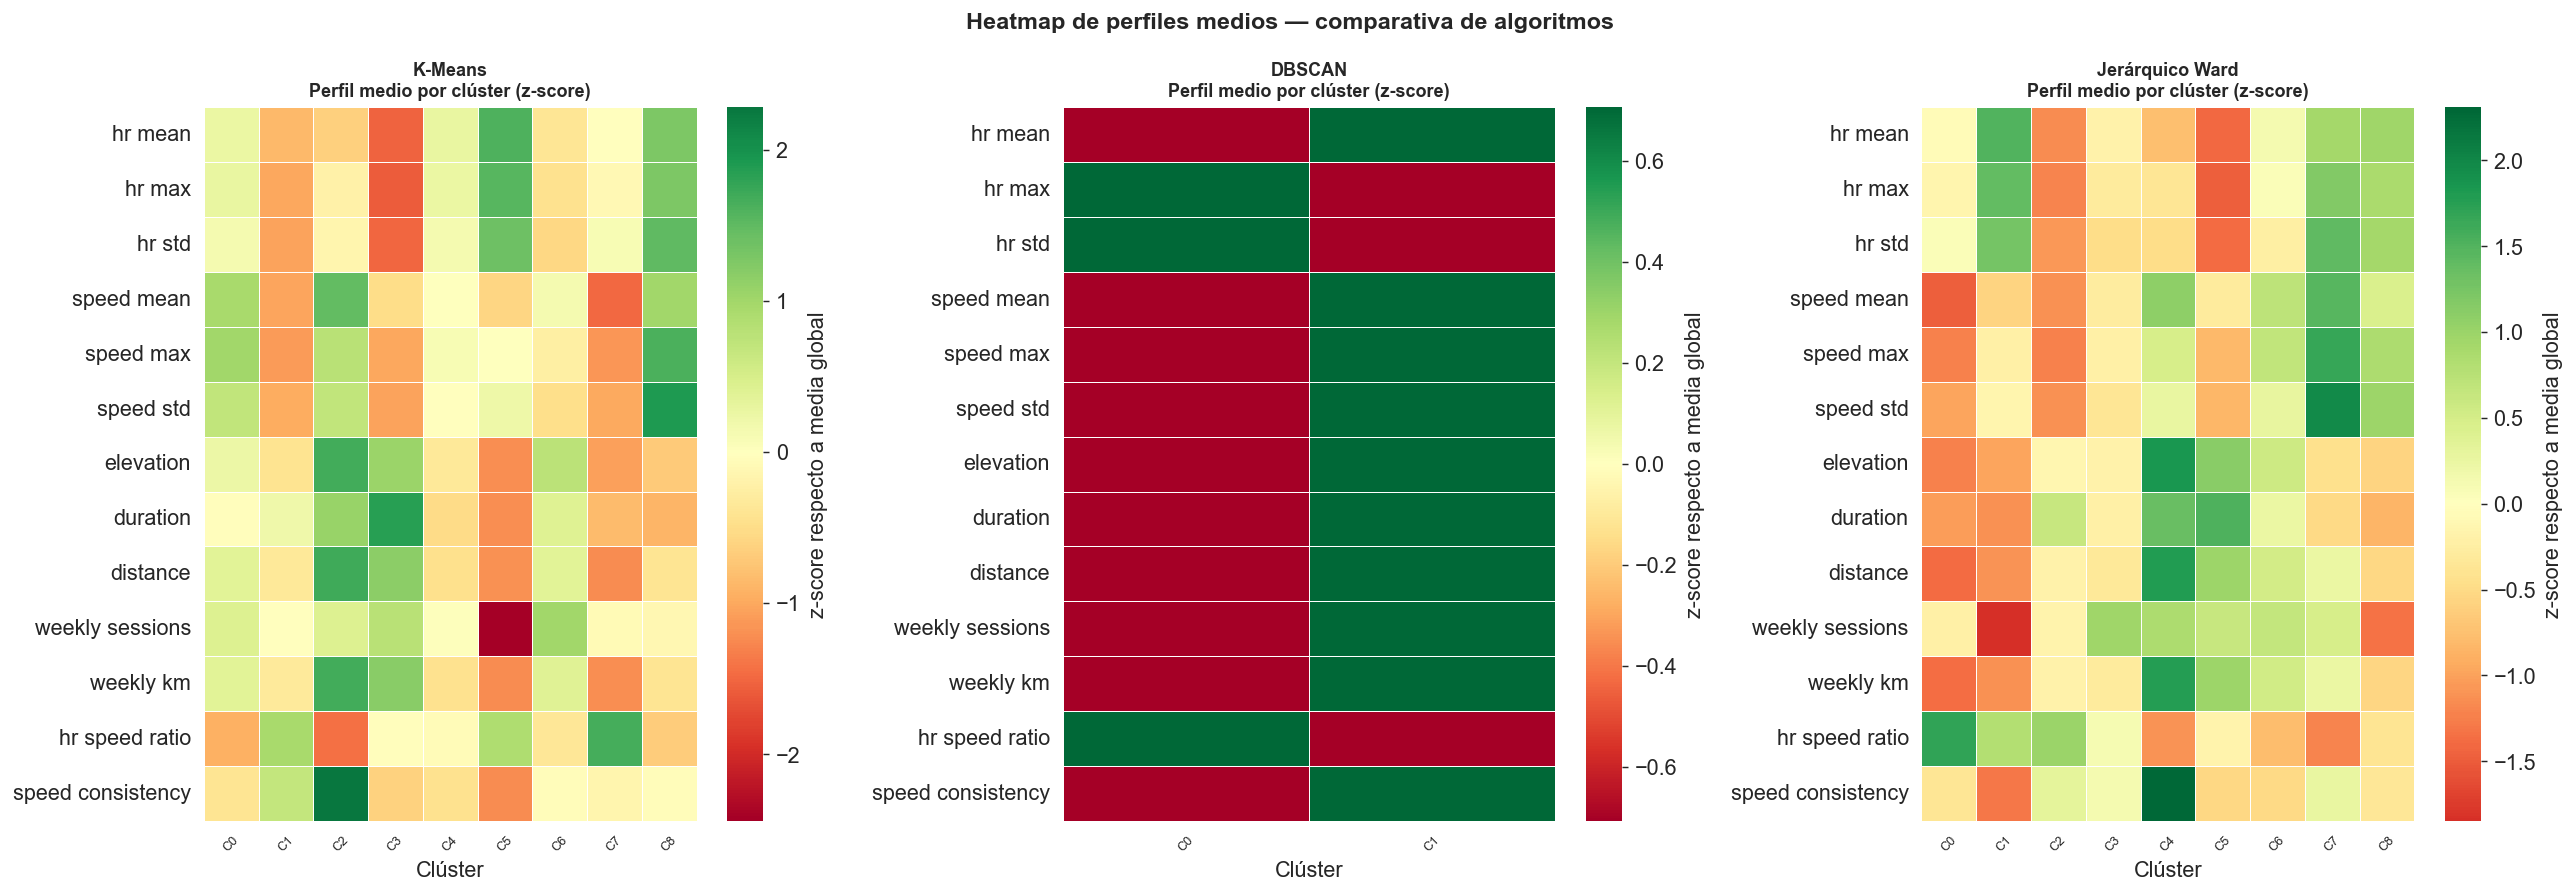

✅ viz3_heatmap_perfiles.png guardado


In [50]:
# ── VIZ 3: Heatmap de perfiles medios por cluster ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, (nombre, labels), color in zip(axes, algos.items(), colors_eval):
    mask   = labels != -1
    df_tmp = X_clean.copy()
    df_tmp["cluster"] = labels

    # Perfil medio por cluster (normalizado al rango [-1, 1] para visualizar)
    stats = (
        df_tmp[mask]
        .groupby("cluster")[FEATURE_COLS]
        .mean()
    )

    # Normalizar por columna
    stats_norm = (stats - stats.mean()) / (stats.std() + 1e-9)

    sns.heatmap(
        stats_norm.T,
        ax=ax,
        cmap="RdYlGn",
        center=0,
        annot=False,
        linewidths=0.5,
        cbar_kws={"label": "z-score respecto a media global"},
        yticklabels=[f.replace("_avg","").replace("_"," ") 
                     for f in FEATURE_COLS],
    )
    ax.set_title(f"{nombre}\nPerfil medio por clúster (z-score)",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Clúster")
    ax.set_xticklabels([f"C{i}" for i in stats.index],
                       rotation=45, fontsize=7)

plt.suptitle("Heatmap de perfiles medios — comparativa de algoritmos",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("viz3_heatmap_perfiles.png", bbox_inches="tight", dpi=130)
plt.show()
print("✅ viz3_heatmap_perfiles.png guardado")

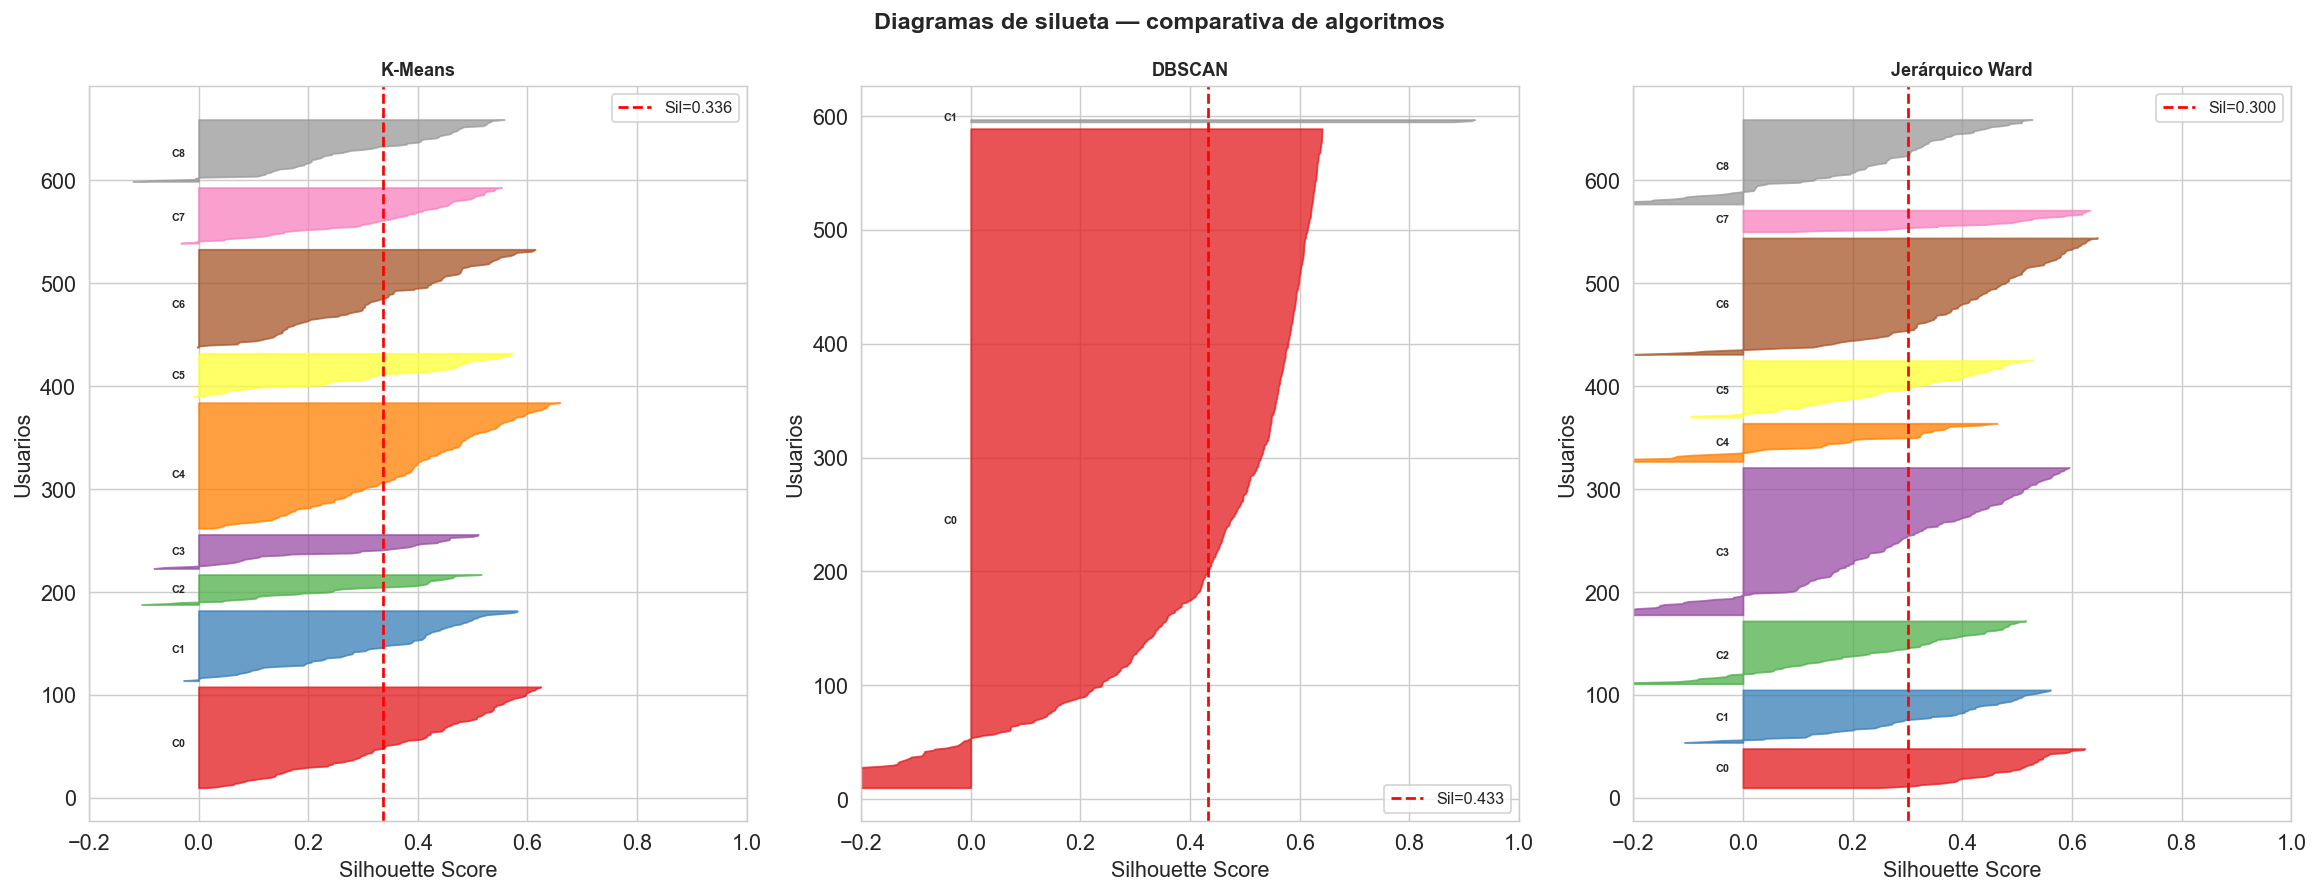

✅ viz4_silueta_comparativa.png guardado


In [54]:
# ── VIZ 4: Diagramas de silueta comparativos ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, (nombre, labels), color in zip(axes, algos.items(), colors_eval):
    mask     = labels != -1
    X_valid  = X_pca[mask]
    l_valid  = labels[mask]

    if len(set(l_valid)) < 2:
        ax.text(0.5, 0.5, "No aplicable\n(<2 clusters)",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_title(nombre)
        continue

    sample_sil = silhouette_samples(X_valid, l_valid)
    sil_medio  = silhouette_score(X_valid, l_valid)
    y_lower    = 10

    clusters_uniq = sorted(set(l_valid))
    colores       = plt.cm.Set1(np.linspace(0, 1, len(clusters_uniq)))

    for i, c in enumerate(clusters_uniq):
        vals    = np.sort(sample_sil[l_valid == c])
        size    = len(vals)
        y_upper = y_lower + size

        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                         facecolor=colores[i],
                         edgecolor=colores[i], alpha=0.75)
        ax.text(-0.05, y_lower + 0.4 * size,
                f"C{c}", fontsize=6, fontweight="bold")
        y_lower = y_upper + 5

    ax.axvline(sil_medio, color="red", linestyle="--", linewidth=1.5,
               label=f"Sil={sil_medio:.3f}")
    ax.set_title(f"{nombre}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Silhouette Score")
    ax.set_ylabel("Usuarios")
    ax.legend(fontsize=9)
    ax.set_xlim([-0.2, 1])

plt.suptitle("Diagramas de silueta — comparativa de algoritmos",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("viz4_silueta_comparativa.png", bbox_inches="tight", dpi=130)
plt.show()
print("✅ viz4_silueta_comparativa.png guardado")

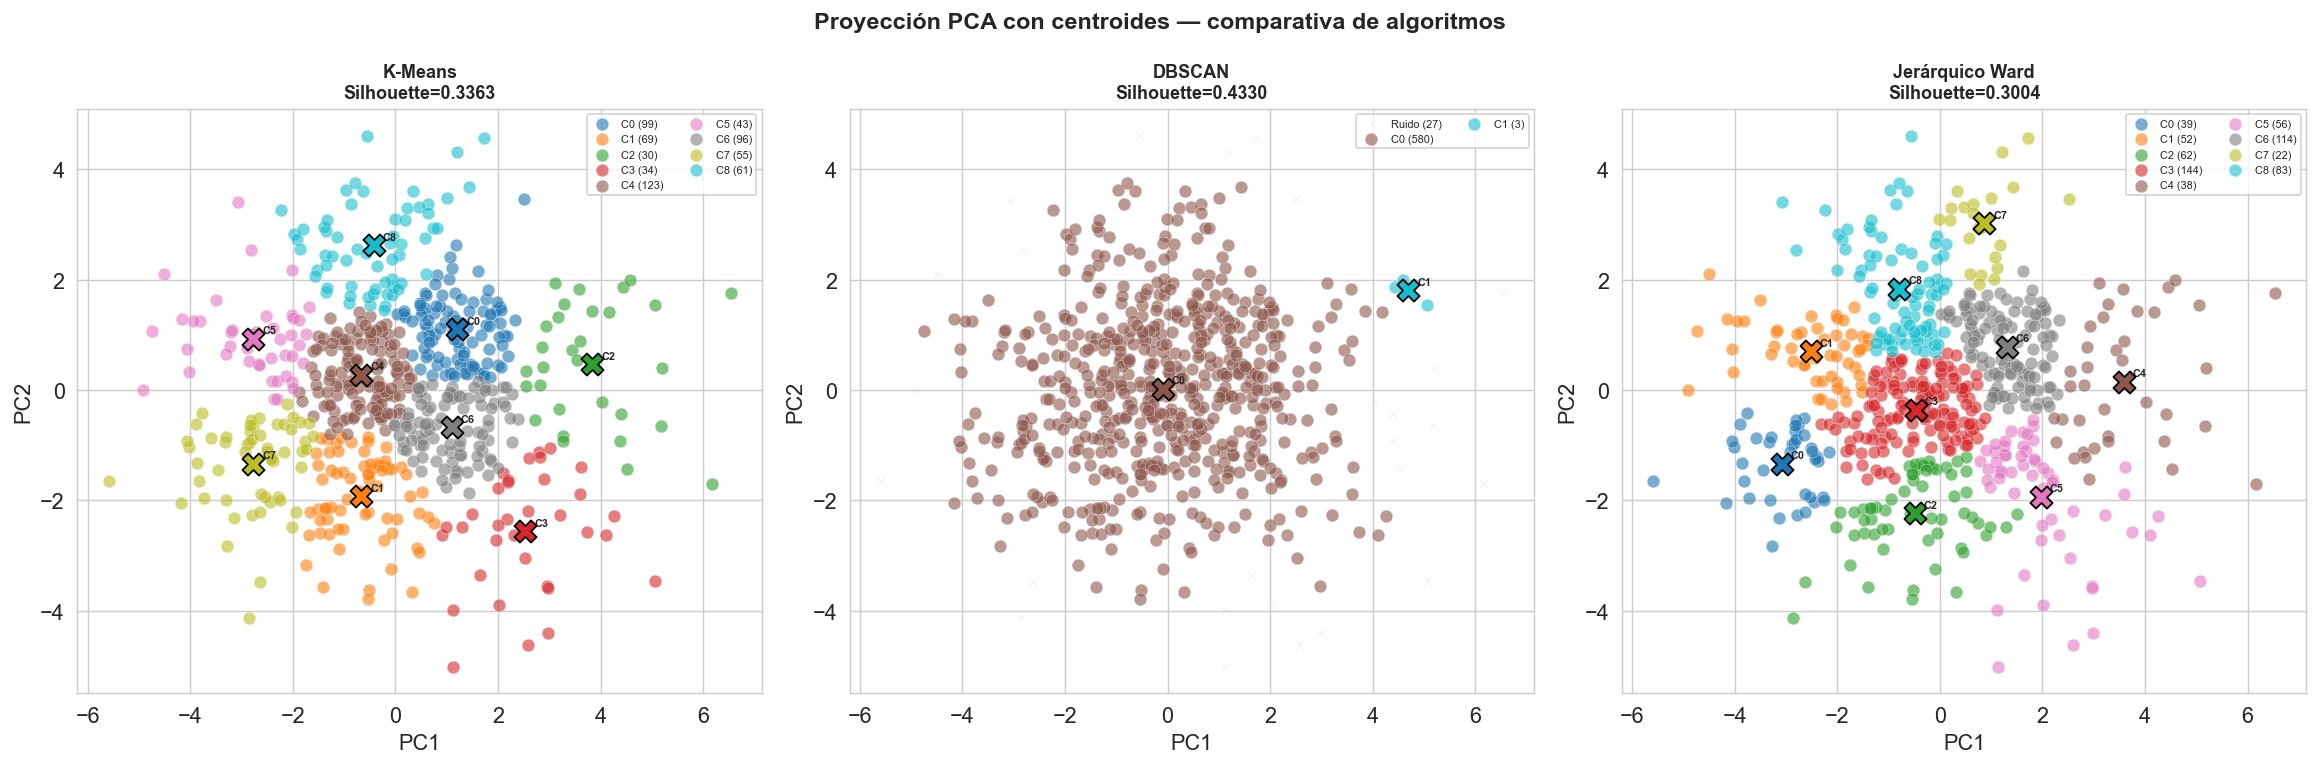

✅ viz5_pca_centroides.png guardado


In [ ]:
# ── VIZ 5: Scatter PCA con centroides de cada algoritmo ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (nombre, labels), color_base in zip(axes, algos.items(), colors_eval):
    clusters_uniq = sorted(set(labels))
    colores       = plt.cm.tab10(np.linspace(0, 1, len(clusters_uniq)))

    for i, c in enumerate(clusters_uniq):
        mask   = labels == c
        label  = f"Ruido ({mask.sum()})" if c == -1 else f"C{c} ({mask.sum()})"
        color  = "lightgray" if c == -1 else colores[i]
        marker = "x" if c == -1 else "o"
        size   = 20 if c == -1 else 50

        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=color, label=label, alpha=0.6,
                   s=size, marker=marker,
                   edgecolors="white" if c != -1 else "none",
                   linewidths=0.3)

        # Centroide de cada cluster (excluir ruido)
        if c != -1:
            cx = X_pca[mask, 0].mean()
            cy = X_pca[mask, 1].mean()
            ax.scatter(cx, cy, c=[colores[i]], marker="X",
                       s=150, zorder=5,
                       edgecolors="black", linewidths=1)
            ax.annotate(f"C{c}", (cx, cy),
                        textcoords="offset points",
                        xytext=(5, 3), fontsize=6, fontweight="bold")

    sil = silhouette_score(
        X_pca[labels != -1], labels[labels != -1]
    ) if len(set(labels[labels != -1])) >= 2 else 0

    ax.set_title(f"{nombre}\nSilhouette={sil:.4f}",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(fontsize=6, ncol=2, loc="upper right")

plt.suptitle("Proyeccion PCA con centroides — comparativa de algoritmos",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("viz5_pca_centroides.png", bbox_inches="tight", dpi=130)
plt.show()
print("✅ viz5_pca_centroides.png guardado")

In [ ]:
# ── VIZ 6: Tabla resumen final exportable ─────────────────────────────────
resumen_final = pd.DataFrame({
    "Algoritmo": ["K-Means", "DBSCAN", "Jerarquico Ward"],
    "k clusters": [
        len(set(labels_km)),
        len(set(labels_db)) - (1 if -1 in labels_db else 0),
        len(set(labels_hier_eval))
    ],
    "Usuarios clasificados": [
        (labels_km != -1).sum(),
        (labels_db != -1).sum(),
        (labels_hier_eval != -1).sum()
    ],
    "Cobertura %": [
        round((labels_km != -1).sum() / len(labels_km) * 100, 1),
        round((labels_db != -1).sum() / len(labels_db) * 100, 1),
        round((labels_hier_eval != -1).sum() / len(labels_hier_eval) * 100, 1)
    ],
    "Silhouette ↑": [
        round(silhouette_score(X_pca, labels_km), 4),
        round(silhouette_score(X_pca[labels_db != -1],
                               labels_db[labels_db != -1]), 4),
        round(silhouette_score(X_pca, labels_hier_eval), 4)
    ],
    "Davies-Bouldin ↓": [
        round(davies_bouldin_score(X_pca, labels_km), 4),
        round(davies_bouldin_score(X_pca[labels_db != -1],
                                   labels_db[labels_db != -1]), 4),
        round(davies_bouldin_score(X_pca, labels_hier_eval), 4)
    ],
    "Calinski-Harabasz ↑": [
        round(calinski_harabasz_score(X_pca, labels_km), 2),
        round(calinski_harabasz_score(X_pca[labels_db != -1],
                                      labels_db[labels_db != -1]), 2),
        round(calinski_harabasz_score(X_pca, labels_hier_eval), 2)
    ],
    "Algoritmo seleccionado": ["✅ SÍ", "❌ NO", "❌ NO"]
}).set_index("Algoritmo")

print("=" * 75)
print("  TABLA RESUMEN FINAL — COMPARATIVA DE ALGORITMOS DE CLUSTERING")
print("  Dataset: Endomondo FitRec | Usuarios: 610 | PCA 2 componentes")
print("=" * 75)
display(resumen_final)

# Guardar como CSV para incluir en el TFM
resumen_final.to_csv("tabla_comparativa_algoritmos.csv")
print("\n✅ tabla_comparativa_algoritmos.csv guardado")
print("\n🏆 Algoritmo seleccionado: K-Means (k=9)")
print("   Justificación: mejor Silhouette, 100% cobertura,")
print("   distribución equilibrada y perfiles interpretables.")

  TABLA RESUMEN FINAL — COMPARATIVA DE ALGORITMOS DE CLUSTERING
  Dataset: Endomondo FitRec | Usuarios: 610 | PCA 2 componentes


,k clusters,Usuarios clasificados,Cobertura %,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑,Algoritmo seleccionado
Algoritmo,,,,,,,
K-Means,9,610,100.0,0.3363,0.8394,367.98,✅ SÍ
DBSCAN,2,583,95.6,0.4330,0.4485,15.79,❌ NO
Jerárquico Ward,9,610,100.0,0.3004,0.9454,310.27,❌ NO



✅ tabla_comparativa_algoritmos.csv guardado

🏆 Algoritmo seleccionado: K-Means (k=9)
   Justificación: mejor Silhouette, 100% cobertura,
   distribución equilibrada y perfiles interpretables.
